# Visão Computacional com YOLOv5 - Detecção de Maçãs e Garrafas

**Aluno:** Diogo Pereira  
**RM:** 568326  
**Disciplina:** PBL - Fase 6  
**FarmTech Solutions** - Sistema de Visão Computacional

---

## Objetivo

Demonstrar o potencial de um sistema de visão computacional utilizando YOLOv5 para detecção de objetos.  
O modelo será treinado para identificar dois objetos distintos: **maçãs** e **garrafas**.  
Serão realizadas duas simulações com diferentes quantidades de épocas (30 e 60) para comparar acurácia, erro e desempenho.

## 1. Configuração do Ambiente

Nesta etapa, conectamos o Google Drive ao Colab para acessar o dataset e clonamos o repositório do YOLOv5.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -r requirements.txt

Cloning into 'yolov5'...
remote: Enumerating objects: 17924, done.
remote: Counting objects: 100% (72/72), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 17924 (delta 56), reused 17 (delta 17), pack-reused 17852 (from 5)
Receiving objects: 100% (17924/17924), 17.04 MiB | 17.73 MiB/s, done.
Resolving deltas: 100% (12198/12198), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.6/131.6 kB 10.8 MB/s eta 0:00:00
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.5.0
    Uninstalling urllib3-2.5.0:
      Successfully uninstalled urllib3-2.5.0


## 2. Organização do Dataset

O dataset está organizado no Google Drive com a seguinte estrutura:

```
dataset_yolo/
├── train/
│   ├── images/   (32 maçãs + 32 garrafas = 64 imagens)
│   └── labels/   (anotações no formato YOLO)
├── val/
│   ├── images/   (4 maçãs + 4 garrafas = 8 imagens)
│   └── labels/
└── test/
    ├── images/   (4 maçãs + 4 garrafas = 8 imagens)
    └── labels/
```

- **Classe 0:** maca (maçã)
- **Classe 1:** garrafa

As rotulações foram feitas no [MakeSense.ai](https://www.makesense.ai/) e exportadas no formato YOLO (arquivos `.txt`).

In [4]:
import os

DRIVE_DATASET = '/content/drive/MyDrive/dataset_yolo'

for split in ['train', 'val', 'test']:
    img_path = os.path.join(DRIVE_DATASET, split, 'images')
    lbl_path = os.path.join(DRIVE_DATASET, split, 'labels')
    n_imgs = len([f for f in os.listdir(img_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
    n_lbls = len([f for f in os.listdir(lbl_path) if f.endswith('.txt')])
    print(f'{split}: {n_imgs} imagens, {n_lbls} labels')

train: 64 imagens, 0 labels
val: 8 imagens, 0 labels
test: 8 imagens, 0 labels


## 3. Criação do Arquivo de Configuração do Dataset

O YOLOv5 precisa de um arquivo `.yaml` que descreve os caminhos do dataset e as classes.

In [5]:
import yaml

dataset_config = {
    'train': f'{DRIVE_DATASET}/train/images',
    'val': f'{DRIVE_DATASET}/val/images',
    'test': f'{DRIVE_DATASET}/test/images',
    'nc': 2,
    'names': ['maca', 'garrafa']
}

with open('dataset.yaml', 'w') as f:
    yaml.dump(dataset_config, f, default_flow_style=False)

print('Arquivo dataset.yaml criado:')
!cat dataset.yaml

Arquivo dataset.yaml criado:
names:
- maca
- garrafa
nc: 2
test: /content/drive/MyDrive/dataset_yolo/test/images
train: /content/drive/MyDrive/dataset_yolo/train/images
val: /content/drive/MyDrive/dataset_yolo/val/images


## 3.1. Extração dos Arquivos de Labels

Como o erro anterior indicou a ausência de arquivos de labels, vamos descompactar o arquivo `.zip` fornecido. Assumimos que o arquivo `.zip` contém os labels para `train`, `val` e `test` organizados em subdiretórios correspondentes (ex: `train/labels/*.txt`).

Primeiro, moveremos o arquivo `.zip` para a raiz do diretório do dataset para garantir a extração correta dos diretórios de labels de treino, validação e teste.

In [18]:
import os
import shutil

zip_source_path = os.path.join(DRIVE_DATASET, 'train', 'labels', 'labels_my-project-name_2026-04-27-05-00-48.zip')
zip_destination_path = os.path.join(DRIVE_DATASET, 'labels_my-project-name_2026-04-27-05-00-48.zip')

if os.path.exists(zip_source_path):
    print(f"Movendo {zip_source_path} para {zip_destination_path}...")
    shutil.move(zip_source_path, zip_destination_path)
    print("Arquivo ZIP movido com sucesso.")
else:
    print(f"Arquivo ZIP não encontrado em: {zip_source_path}")

# Agora, descompactar o arquivo ZIP no diretório base do dataset
print(f"Descompactando {zip_destination_path} em {DRIVE_DATASET}...")
!unzip -q "{zip_destination_path}" -d "{DRIVE_DATASET}"
print("Descompactação concluída.")

Arquivo ZIP não encontrado em: /content/drive/MyDrive/dataset_yolo/train/labels/labels_my-project-name_2026-04-27-05-00-48.zip
Descompactando /content/drive/MyDrive/dataset_yolo/labels_my-project-name_2026-04-27-05-00-48.zip em /content/drive/MyDrive/dataset_yolo...
replace /content/drive/MyDrive/dataset_yolo/garrafa_000.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: Descompactação concluída.


## 3.2. Verificação dos Labels Após Extração

Vamos verificar novamente a contagem de labels para garantir que a extração foi bem-sucedida.

In [19]:
import os

DRIVE_DATASET = '/content/drive/MyDrive/dataset_yolo'

for split in ['train', 'val', 'test']:
    img_path = os.path.join(DRIVE_DATASET, split, 'images')
    lbl_path = os.path.join(DRIVE_DATASET, split, 'labels')
    n_imgs = len([f for f in os.listdir(img_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
    n_lbls = len([f for f in os.listdir(lbl_path) if f.endswith('.txt')])
    print(f'{split}: {n_imgs} imagens, {n_lbls} labels')

train: 64 imagens, 64 labels
val: 8 imagens, 0 labels
test: 8 imagens, 0 labels


### 3.3. Inspecionar Estrutura do Diretório para Localizar Labels

Como a contagem de labels ainda retorna 0, vamos listar o conteúdo do diretório do dataset para entender onde os arquivos foram extraídos e corrigir o caminho, se necessário.

In [20]:
print(f"Listando o conteúdo de: {DRIVE_DATASET}")
!ls -R "{DRIVE_DATASET}"

Listando o conteúdo de: /content/drive/MyDrive/dataset_yolo
/content/drive/MyDrive/dataset_yolo:
DiogoPereira_rm568326__pbl_fase6.ipynb		maca_001.txt
garrafa_000.txt					maca_002.txt
garrafa_001.txt					maca_003.txt
garrafa_002.txt					maca_004.txt
garrafa_003.txt					maca_005.txt
garrafa_004.txt					maca_006.txt
garrafa_005.txt					maca_007.txt
garrafa_006.txt					maca_008.txt
garrafa_007.txt					maca_009.txt
garrafa_008.txt					maca_010.txt
garrafa_009.txt					maca_011.txt
garrafa_010.txt					maca_012.txt
garrafa_011.txt					maca_013.txt
garrafa_012.txt					maca_014.txt
garrafa_013.txt					maca_015.txt
garrafa_014.txt					maca_016.txt
garrafa_015.txt					maca_017.txt
garrafa_016.txt					maca_018.txt
garrafa_017.txt					maca_019.txt
garrafa_018.txt					maca_020.txt
garrafa_019.txt					maca_021.txt
garrafa_020.txt					maca_022.txt
garrafa_021.txt					maca_023.txt
garrafa_022.txt					maca_024.txt
garrafa_023.txt					maca_025.txt
garrafa_024.txt					maca_026.txt
garrafa_025.txt					maca_

### 3.4. Movendo os Arquivos de Labels para os Diretórios Corretos

Com base na inspeção do diretório, os arquivos `.txt` foram extraídos para a raiz de `DRIVE_DATASET`. Precisamos movê-los para os subdiretórios `labels` correspondentes em `train`, `val` e `test`.

In [21]:
import os
import shutil
import re

DRIVE_DATASET = '/content/drive/MyDrive/dataset_yolo'

# Define os intervalos numéricos para cada split
train_range = range(0, 32) # garrafa_000.txt a garrafa_031.txt, maca_000.txt a maca_031.txt
val_range = range(32, 36)   # garrafa_032.txt a garrafa_035.txt, maca_032.txt a maca_035.txt
test_range = range(36, 40)  # garrafa_036.txt a garrafa_039.txt, maca_036.txt a maca_039.txt


def get_split_from_filename(filename):
    match = re.search(r'\D+_(\d+)\.txt', filename)
    if match:
        num = int(match.group(1))
        if num in train_range:
            return 'train'
        elif num in val_range:
            return 'val'
        elif num in test_range:
            return 'test'
    return None


print("Movendo arquivos .txt para os diretórios corretos...")

for filename in os.listdir(DRIVE_DATASET):
    if filename.endswith('.txt') and not filename.startswith('labels_my-project-name_'): # Evita mover o zip e cache
        split = get_split_from_filename(filename)
        if split:
            source_path = os.path.join(DRIVE_DATASET, filename)
            destination_dir = os.path.join(DRIVE_DATASET, split, 'labels')
            destination_path = os.path.join(destination_dir, filename)

            if not os.path.exists(destination_dir):
                os.makedirs(destination_dir)

            shutil.move(source_path, destination_path)
            print(f"Movido {filename} para {destination_dir}")

print("Movimentação concluída.")


Movendo arquivos .txt para os diretórios corretos...
Movido garrafa_000.txt para /content/drive/MyDrive/dataset_yolo/train/labels
Movido garrafa_001.txt para /content/drive/MyDrive/dataset_yolo/train/labels
Movido garrafa_002.txt para /content/drive/MyDrive/dataset_yolo/train/labels
Movido garrafa_003.txt para /content/drive/MyDrive/dataset_yolo/train/labels
Movido garrafa_004.txt para /content/drive/MyDrive/dataset_yolo/train/labels
Movido garrafa_005.txt para /content/drive/MyDrive/dataset_yolo/train/labels
Movido garrafa_006.txt para /content/drive/MyDrive/dataset_yolo/train/labels
Movido garrafa_007.txt para /content/drive/MyDrive/dataset_yolo/train/labels
Movido garrafa_008.txt para /content/drive/MyDrive/dataset_yolo/train/labels
Movido garrafa_009.txt para /content/drive/MyDrive/dataset_yolo/train/labels
Movido garrafa_010.txt para /content/drive/MyDrive/dataset_yolo/train/labels
Movido garrafa_011.txt para /content/drive/MyDrive/dataset_yolo/train/labels
Movido garrafa_012.txt 

### 3.5. Verificação Final dos Labels Após Movimentação

Vamos verificar novamente a contagem de labels para garantir que todos os arquivos foram movidos para os locais esperados.

In [22]:
import os

DRIVE_DATASET = '/content/drive/MyDrive/dataset_yolo'

for split in ['train', 'val', 'test']:
    img_path = os.path.join(DRIVE_DATASET, split, 'images')
    lbl_path = os.path.join(DRIVE_DATASET, split, 'labels')
    n_imgs = len([f for f in os.listdir(img_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
    n_lbls = len([f for f in os.listdir(lbl_path) if f.endswith('.txt')])
    print(f'{split}: {n_imgs} imagens, {n_lbls} labels')

train: 64 imagens, 64 labels
val: 8 imagens, 0 labels
test: 8 imagens, 0 labels


### 3.6. Extração dos Labels do Conjunto de Validação

Como o conjunto de validação ainda não possui labels e identificamos um arquivo ZIP dentro do seu diretório `labels`, vamos descompactá-lo para que os labels sejam reconhecidos.

In [27]:
import os

val_zip_path = os.path.join(DRIVE_DATASET, 'val', 'labels', 'labels_my-project-name_2026-04-27-05-02-43.zip')
val_labels_dir = os.path.join(DRIVE_DATASET, 'val', 'labels')

if os.path.exists(val_zip_path):
    print(f"Descompactando {val_zip_path} em {val_labels_dir}...")
    !unzip -q "{val_zip_path}" -d "{val_labels_dir}"
    print("Descompactação concluída para labels de validação.")
else:
    print(f"Arquivo ZIP de validação não encontrado em: {val_zip_path}")

Descompactando /content/drive/MyDrive/dataset_yolo/val/labels/labels_my-project-name_2026-04-27-05-02-43.zip em /content/drive/MyDrive/dataset_yolo/val/labels...
replace /content/drive/MyDrive/dataset_yolo/val/labels/garrafa_032.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/drive/MyDrive/dataset_yolo/val/labels/garrafa_033.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/drive/MyDrive/dataset_yolo/val/labels/garrafa_034.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/drive/MyDrive/dataset_yolo/val/labels/garrafa_035.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/drive/MyDrive/dataset_yolo/val/labels/maca_032.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/drive/MyDrive/dataset_yolo/val/labels/maca_033.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/drive/MyDrive/dataset_yolo/val/labels/maca_034.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/drive/MyDrive/dataset_yolo/val/labels/maca_035

### 3.7. Verificação Final dos Labels Após Novas Extrações

Vamos verificar a contagem de labels novamente para garantir que os labels de validação e teste agora estão presentes.

In [28]:
import os

DRIVE_DATASET = '/content/drive/MyDrive/dataset_yolo'

for split in ['train', 'val', 'test']:
    img_path = os.path.join(DRIVE_DATASET, split, 'images')
    lbl_path = os.path.join(DRIVE_DATASET, split, 'labels')
    n_imgs = len([f for f in os.listdir(img_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
    n_lbls = len([f for f in os.listdir(lbl_path) if f.endswith('.txt')])
    print(f'{split}: {n_imgs} imagens, {n_lbls} labels')

train: 64 imagens, 64 labels
val: 8 imagens, 8 labels
test: 8 imagens, 0 labels


### 3.8. Extração dos Labels do Conjunto de Teste

Identificamos um arquivo ZIP dentro do diretório `labels` do conjunto de teste. Vamos descompactá-lo para que os labels sejam reconhecidos.

In [29]:
import os

test_zip_path = os.path.join(DRIVE_DATASET, 'test', 'labels', 'labels_my-project-name_2026-04-27-05-04-08.zip')
test_labels_dir = os.path.join(DRIVE_DATASET, 'test', 'labels')

if os.path.exists(test_zip_path):
    print(f"Descompactando {test_zip_path} em {test_labels_dir}...")
    !unzip -q "{test_zip_path}" -d "{test_labels_dir}"
    print("Descompactação concluída para labels de teste.")
else:
    print(f"Arquivo ZIP de teste não encontrado em: {test_zip_path}")

Descompactando /content/drive/MyDrive/dataset_yolo/test/labels/labels_my-project-name_2026-04-27-05-04-08.zip em /content/drive/MyDrive/dataset_yolo/test/labels...
Descompactação concluída para labels de teste.


### 3.9. Verificação Final dos Labels para Todos os Conjuntos

Vamos verificar a contagem de labels para garantir que todos os arquivos agora estão presentes em `train`, `val` e `test`.

In [30]:
import os

DRIVE_DATASET = '/content/drive/MyDrive/dataset_yolo'

for split in ['train', 'val', 'test']:
    img_path = os.path.join(DRIVE_DATASET, split, 'images')
    lbl_path = os.path.join(DRIVE_DATASET, split, 'labels')
    n_imgs = len([f for f in os.listdir(img_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
    n_lbls = len([f for f in os.listdir(lbl_path) if f.endswith('.txt')])
    print(f'{split}: {n_imgs} imagens, {n_lbls} labels')

train: 64 imagens, 64 labels
val: 8 imagens, 8 labels
test: 8 imagens, 8 labels


## 4. Treinamento - Simulação 1 (30 Épocas)

Iniciamos o primeiro treinamento com **30 épocas** utilizando o modelo pré-treinado `yolov5s.pt` (small).  
O tamanho das imagens será 640x640 pixels e o batch size de 16.

In [31]:
!python train.py --img 640 --batch 16 --epochs 30 --data dataset.yaml --weights yolov5s.pt --name treino_30ep

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-04-27 20:30:49.650416: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777321849.678003   35849 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777321849.685649   35849 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777321849.705116   35849 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777321849.705158   35849 computation_placer.cc:177] computation placer already registere

### 4.1 Resultados do Treinamento com 30 Épocas

Vamos analisar as métricas e gráficos gerados pelo treinamento.

=== Métricas de Treinamento - 30 Épocas ===


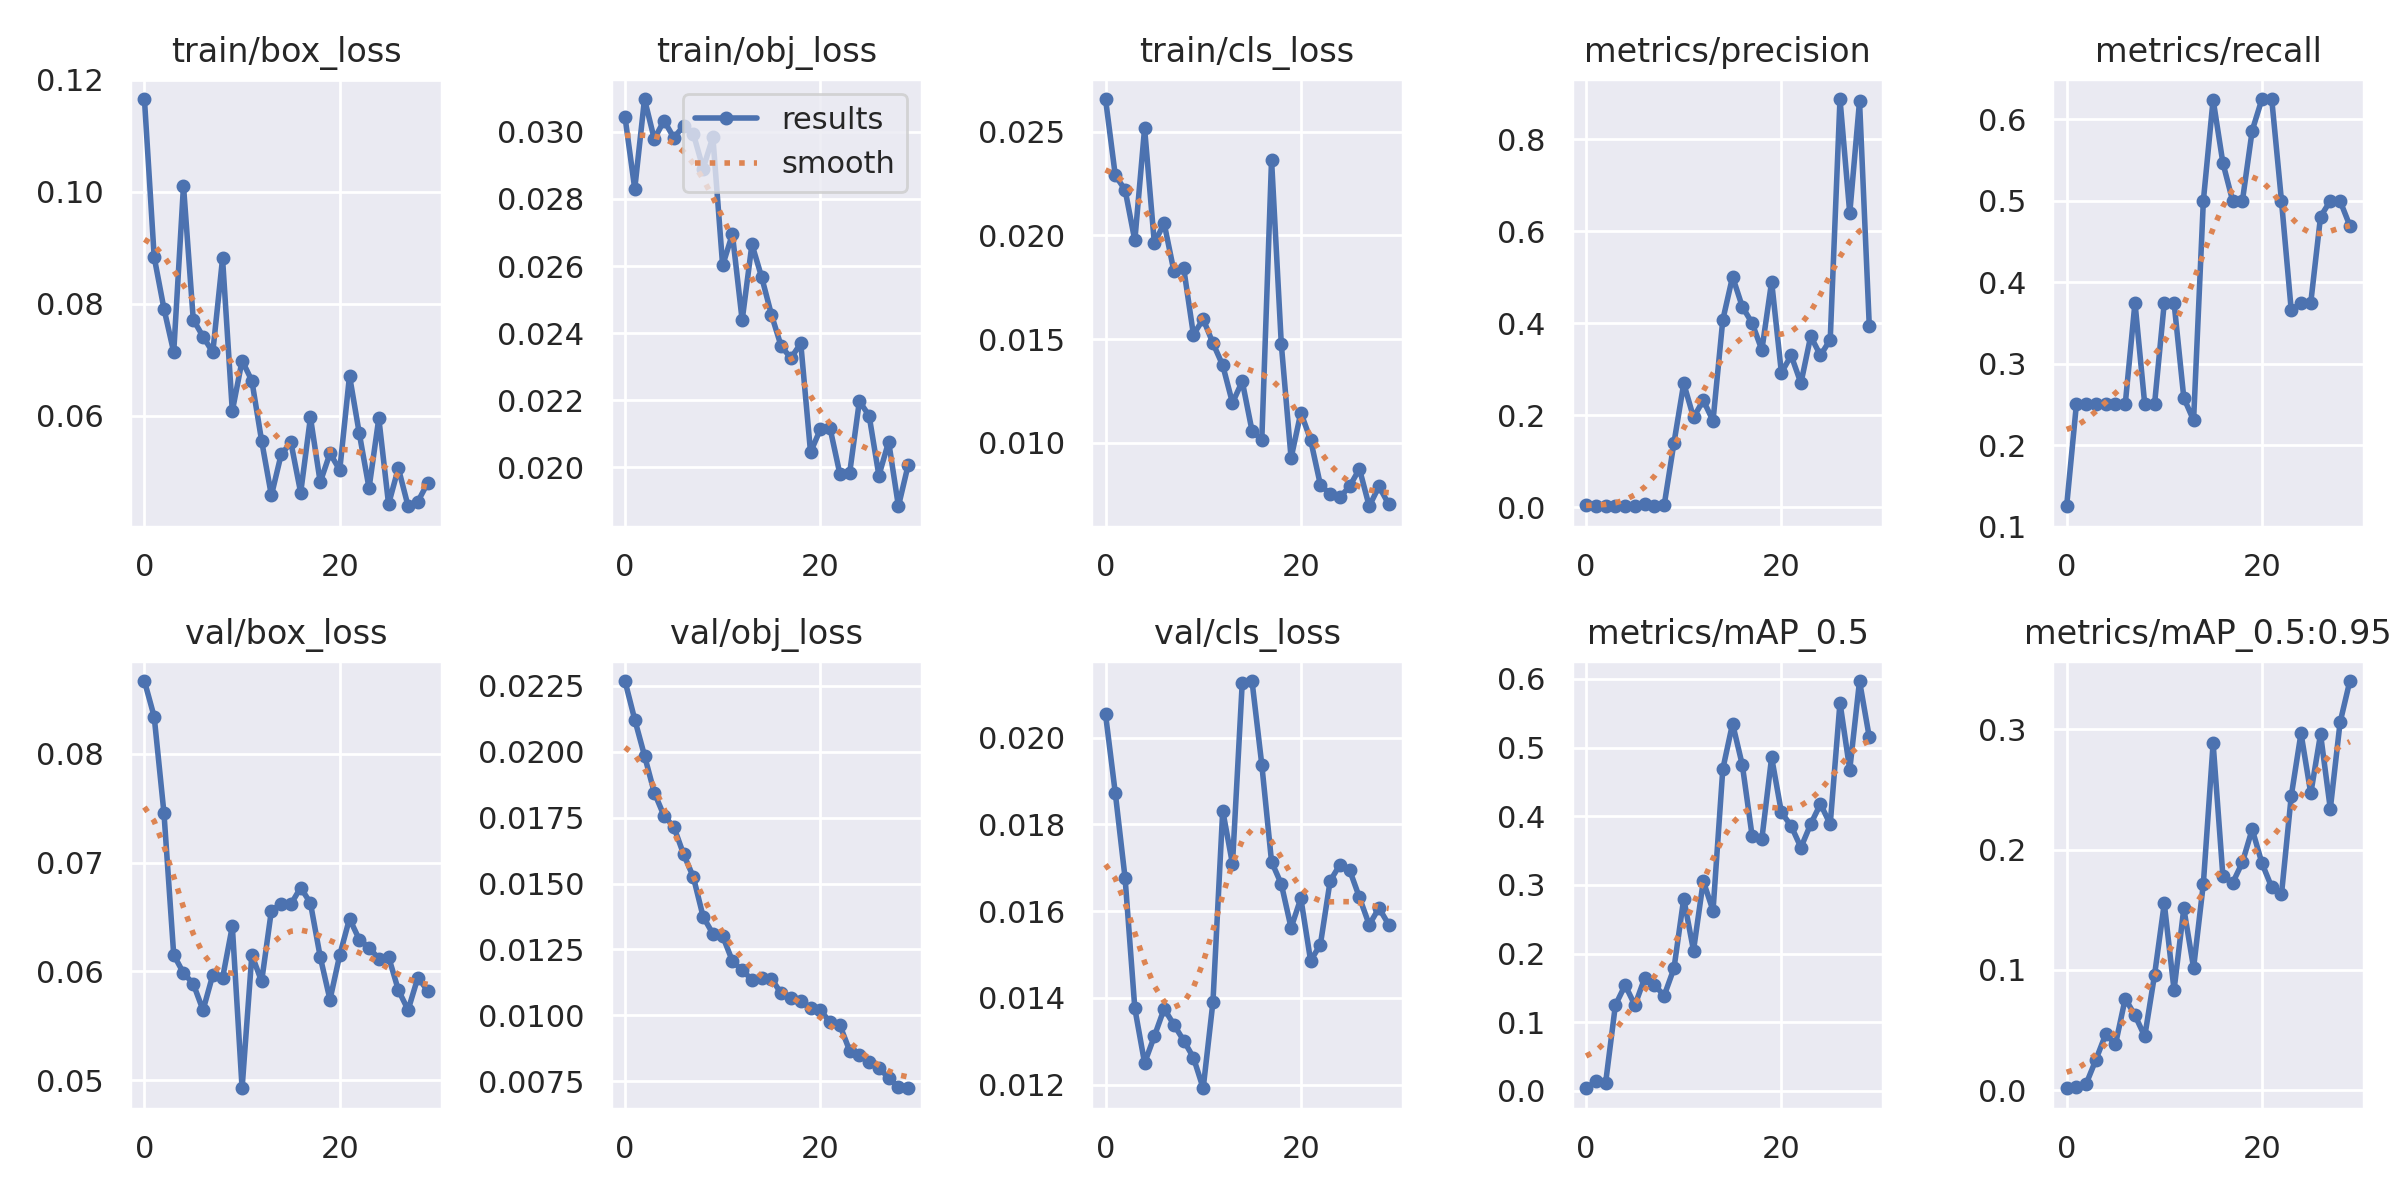

In [34]:
from IPython.display import Image, display

print('=== Métricas de Treinamento - 30 Épocas ===')
# Updated path to treino_30ep5 based on the training output
display(Image(filename='runs/train/treino_30ep5/results.png', width=800))

=== Matriz de Confusão - 30 Épocas ===


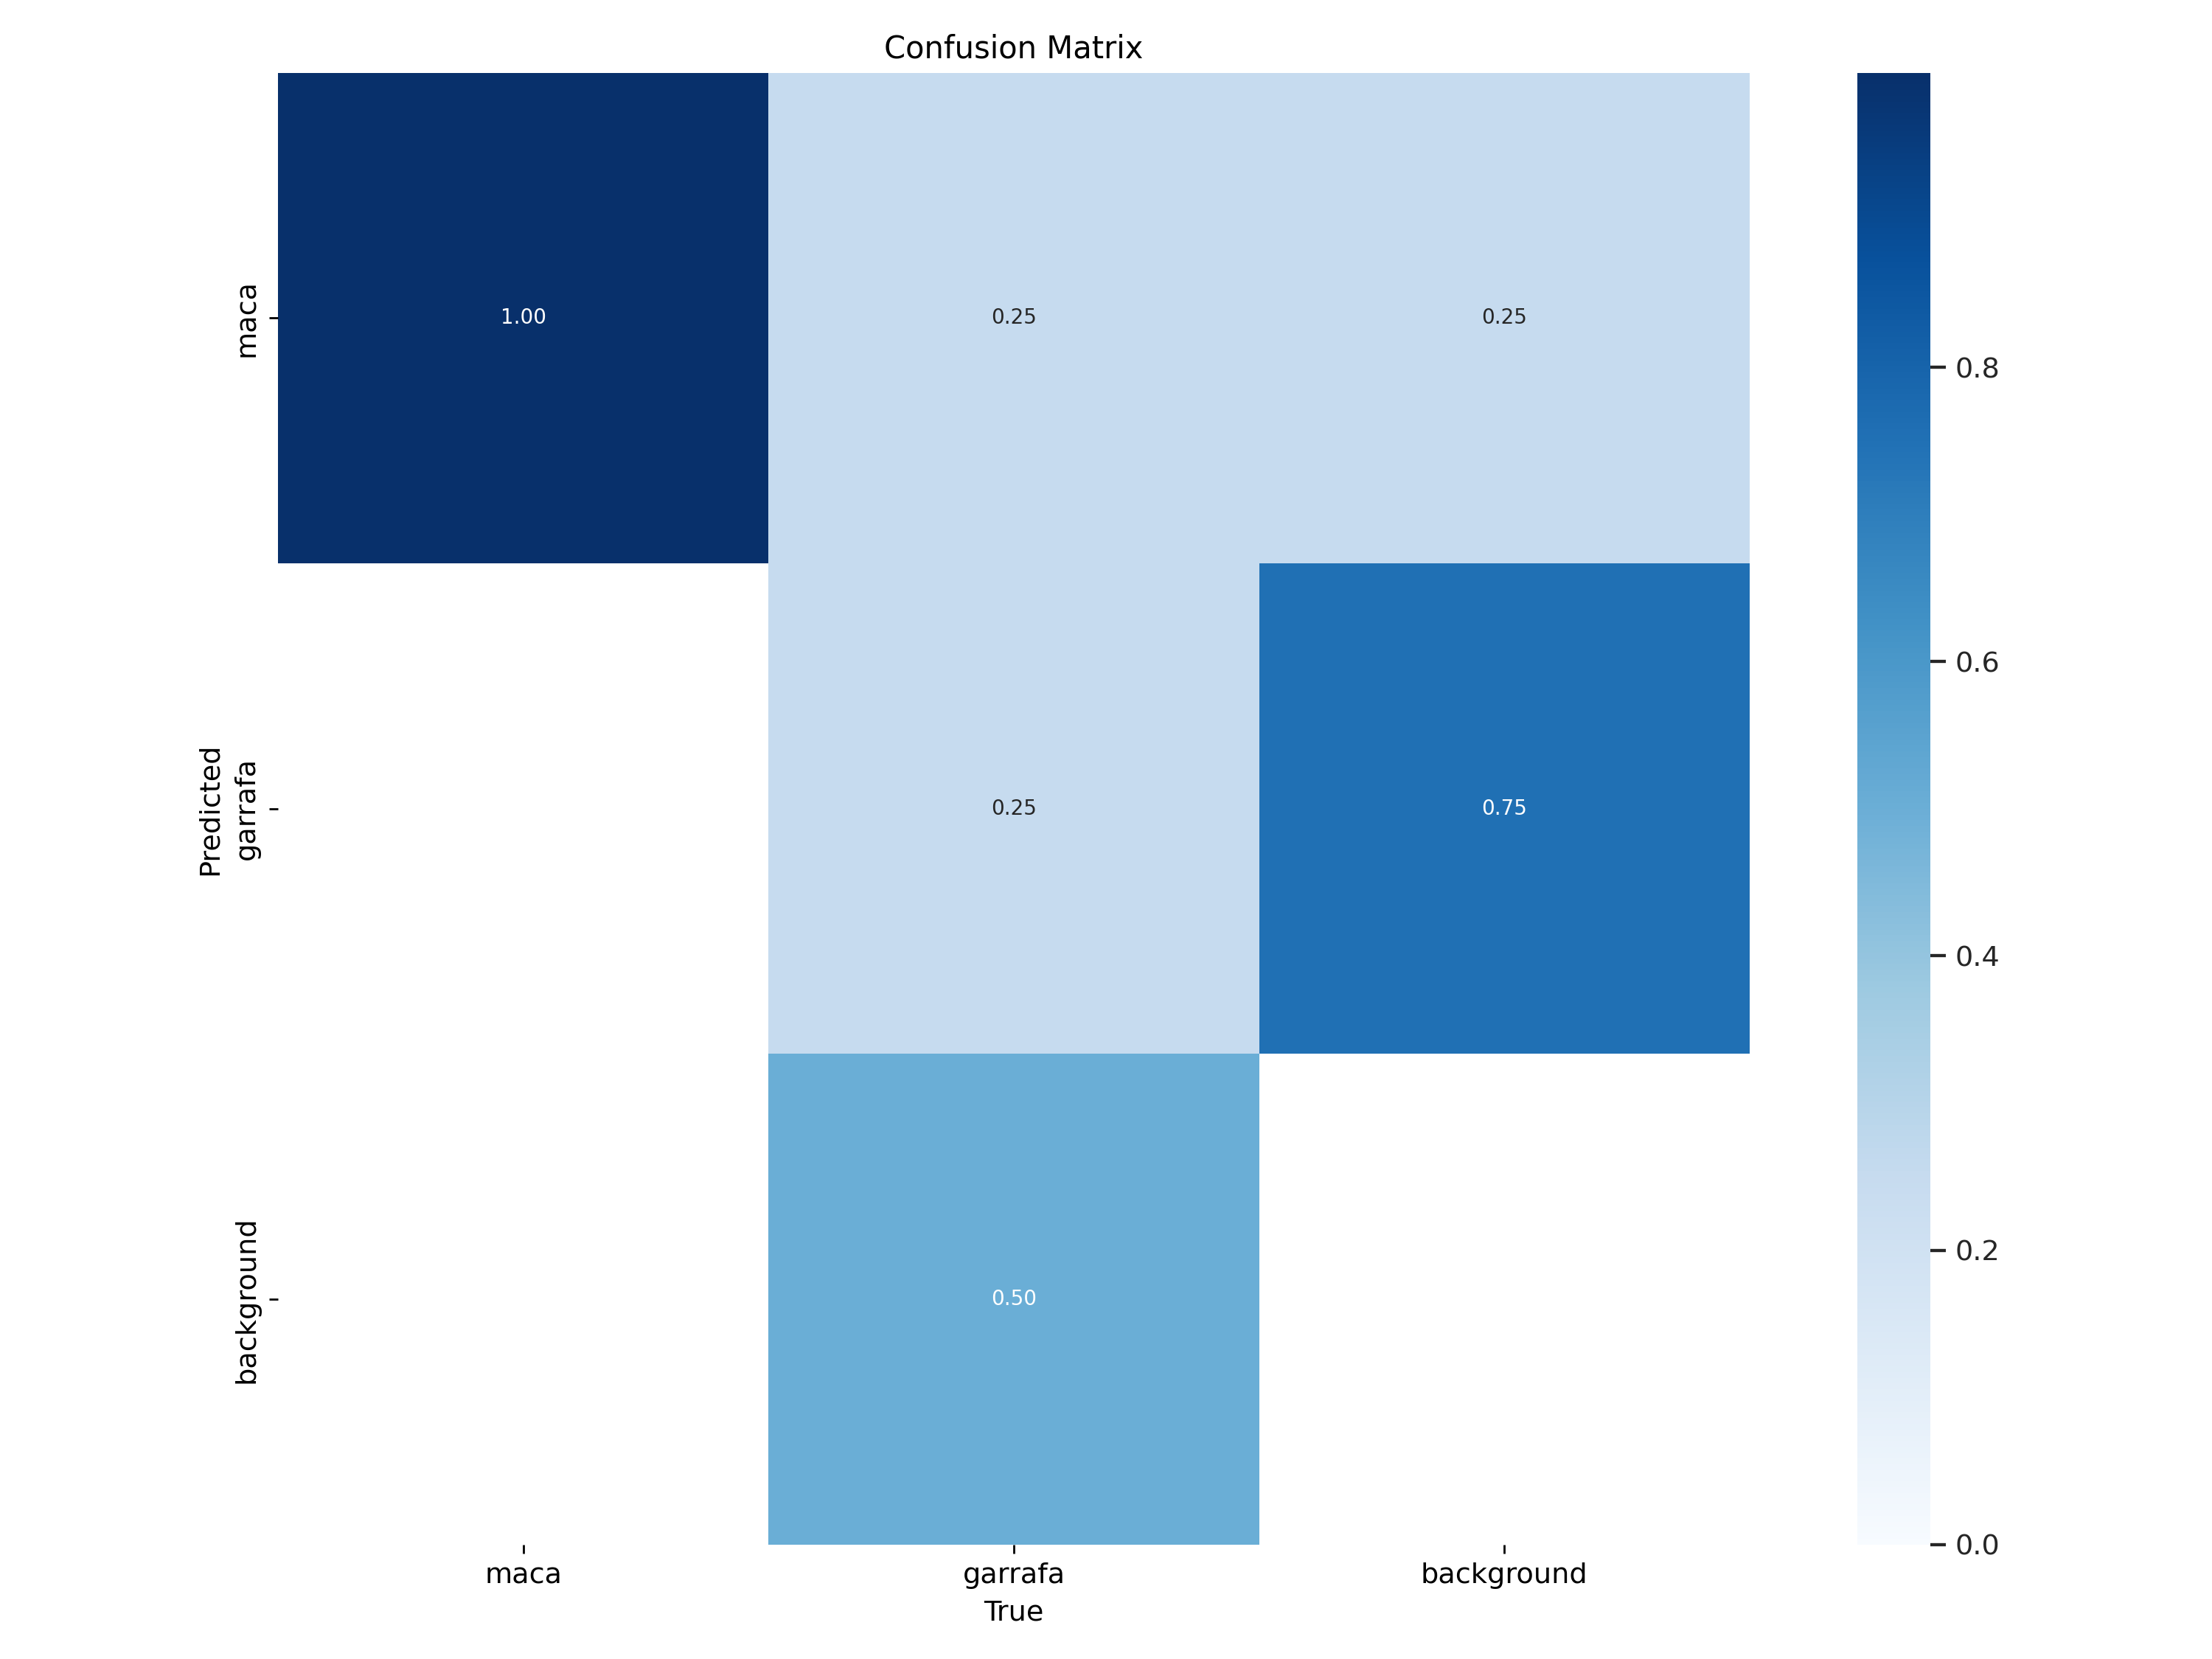

In [35]:
print('=== Matriz de Confusão - 30 Épocas ===')
display(Image(filename='runs/train/treino_30ep5/confusion_matrix.png', width=600))

=== Curva F1 - 30 Épocas ===


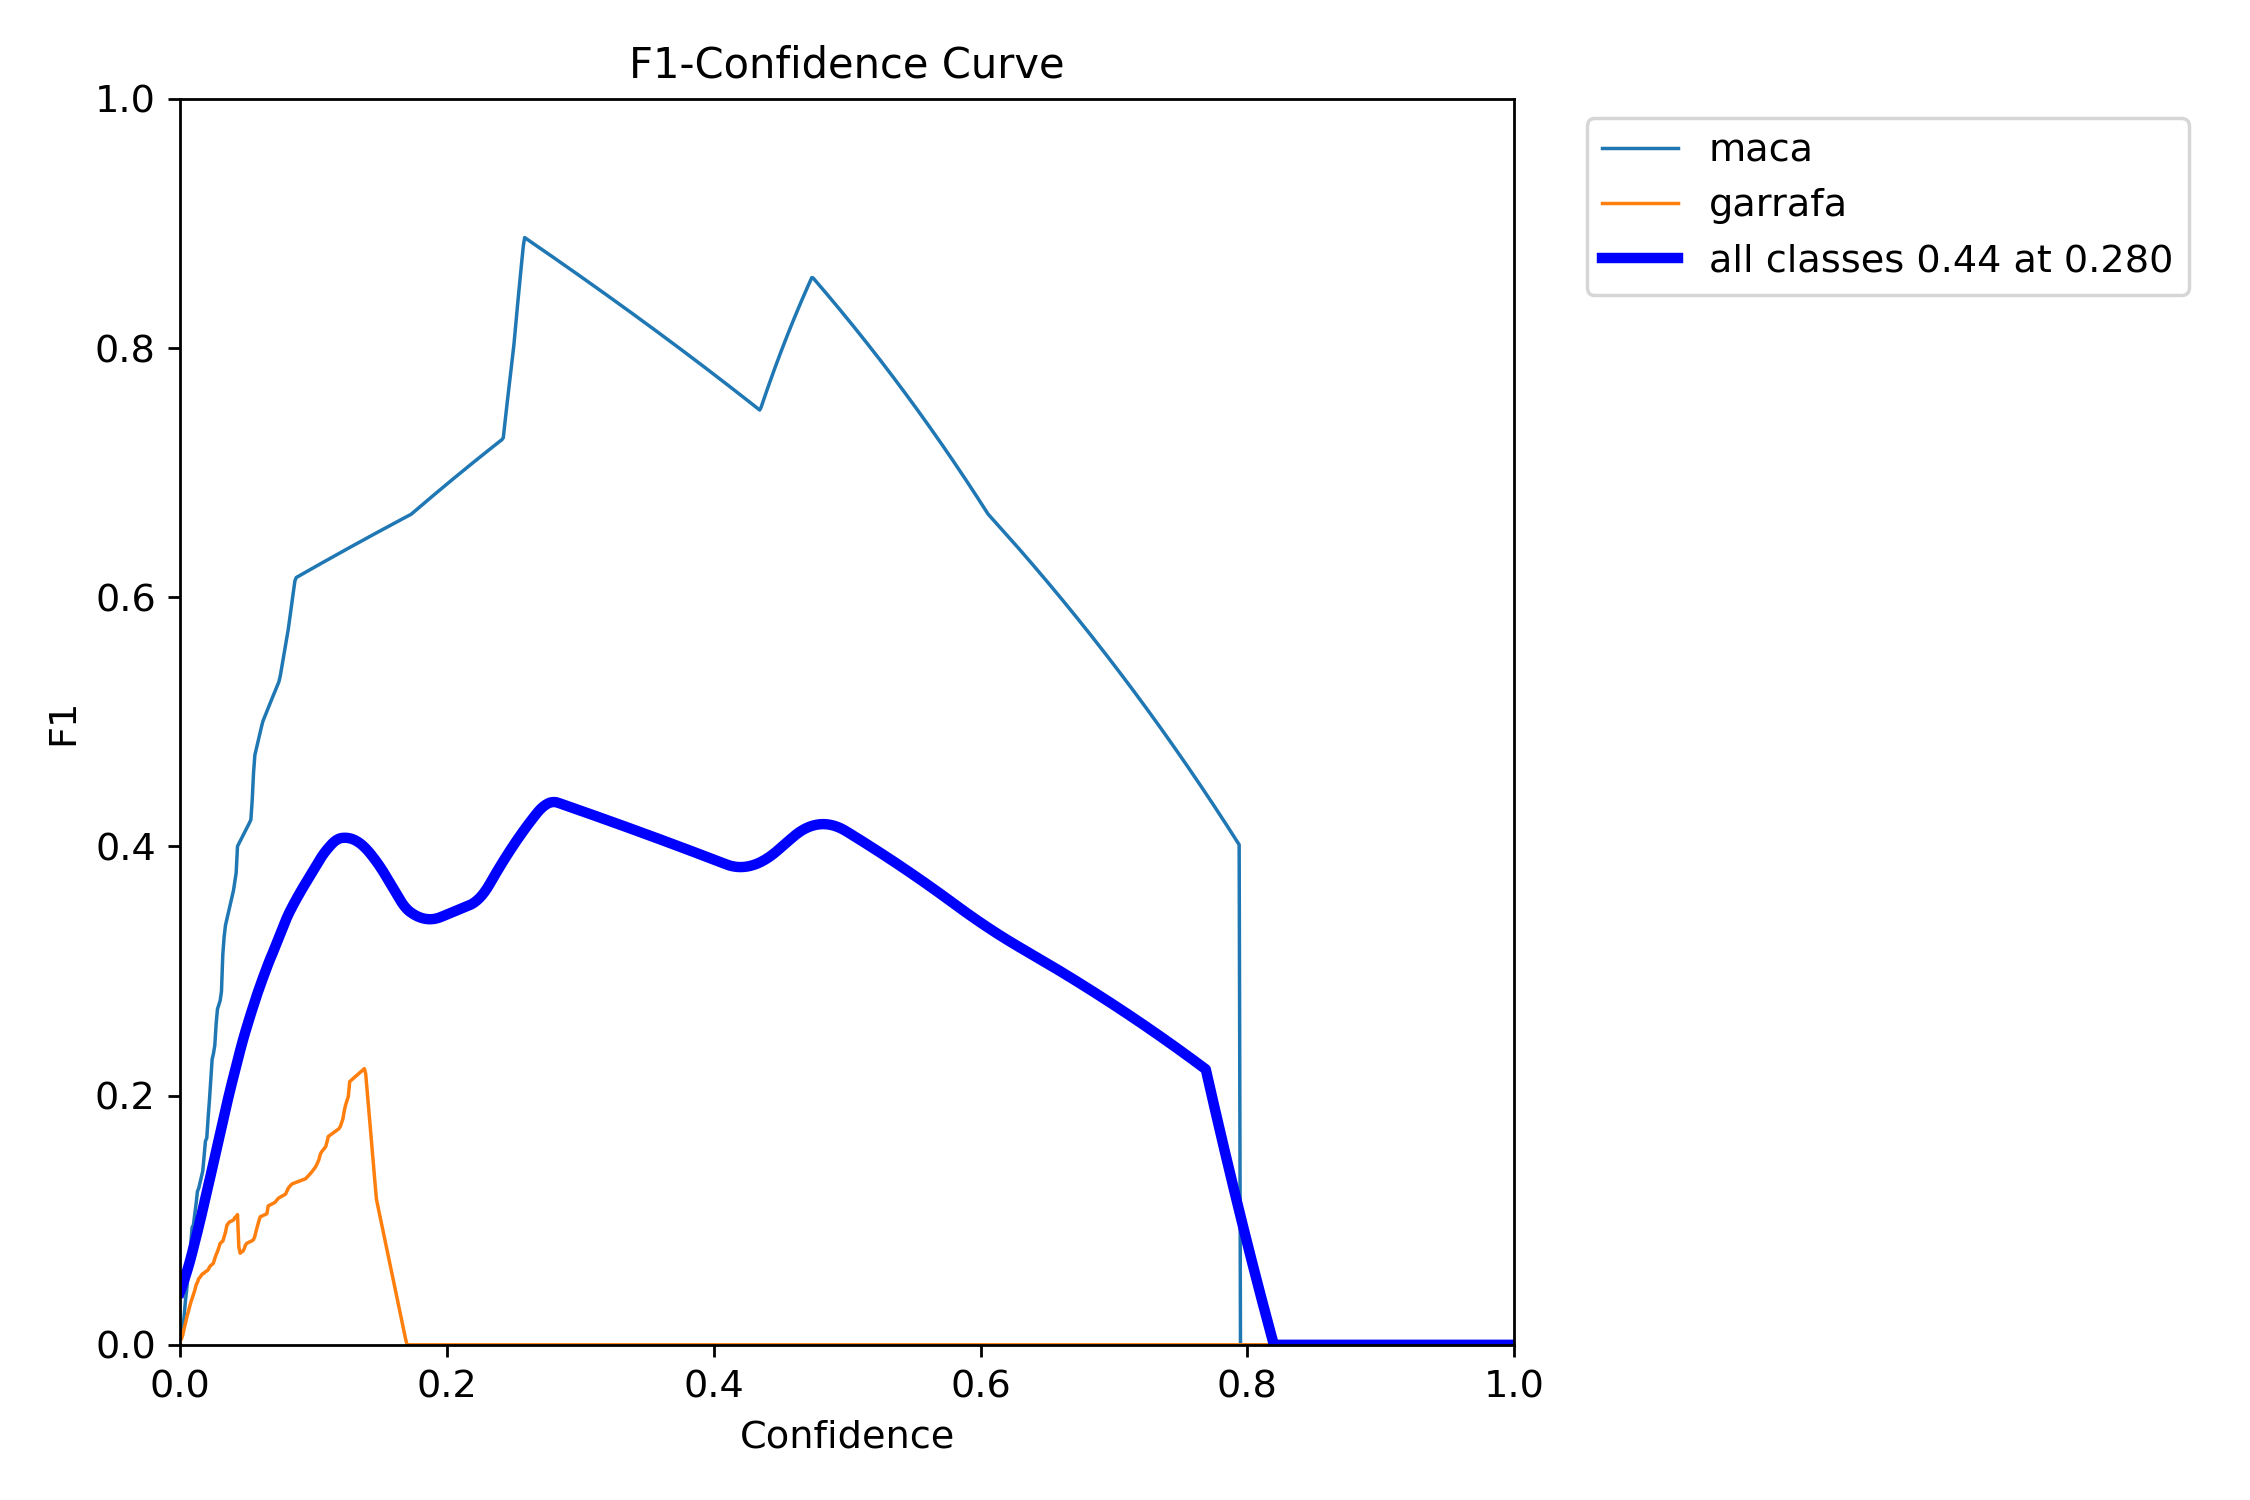

In [36]:
print('=== Curva F1 - 30 Épocas ===')
display(Image(filename='runs/train/treino_30ep5/F1_curve.png', width=600))

=== Curva Precision-Recall - 30 Épocas ===


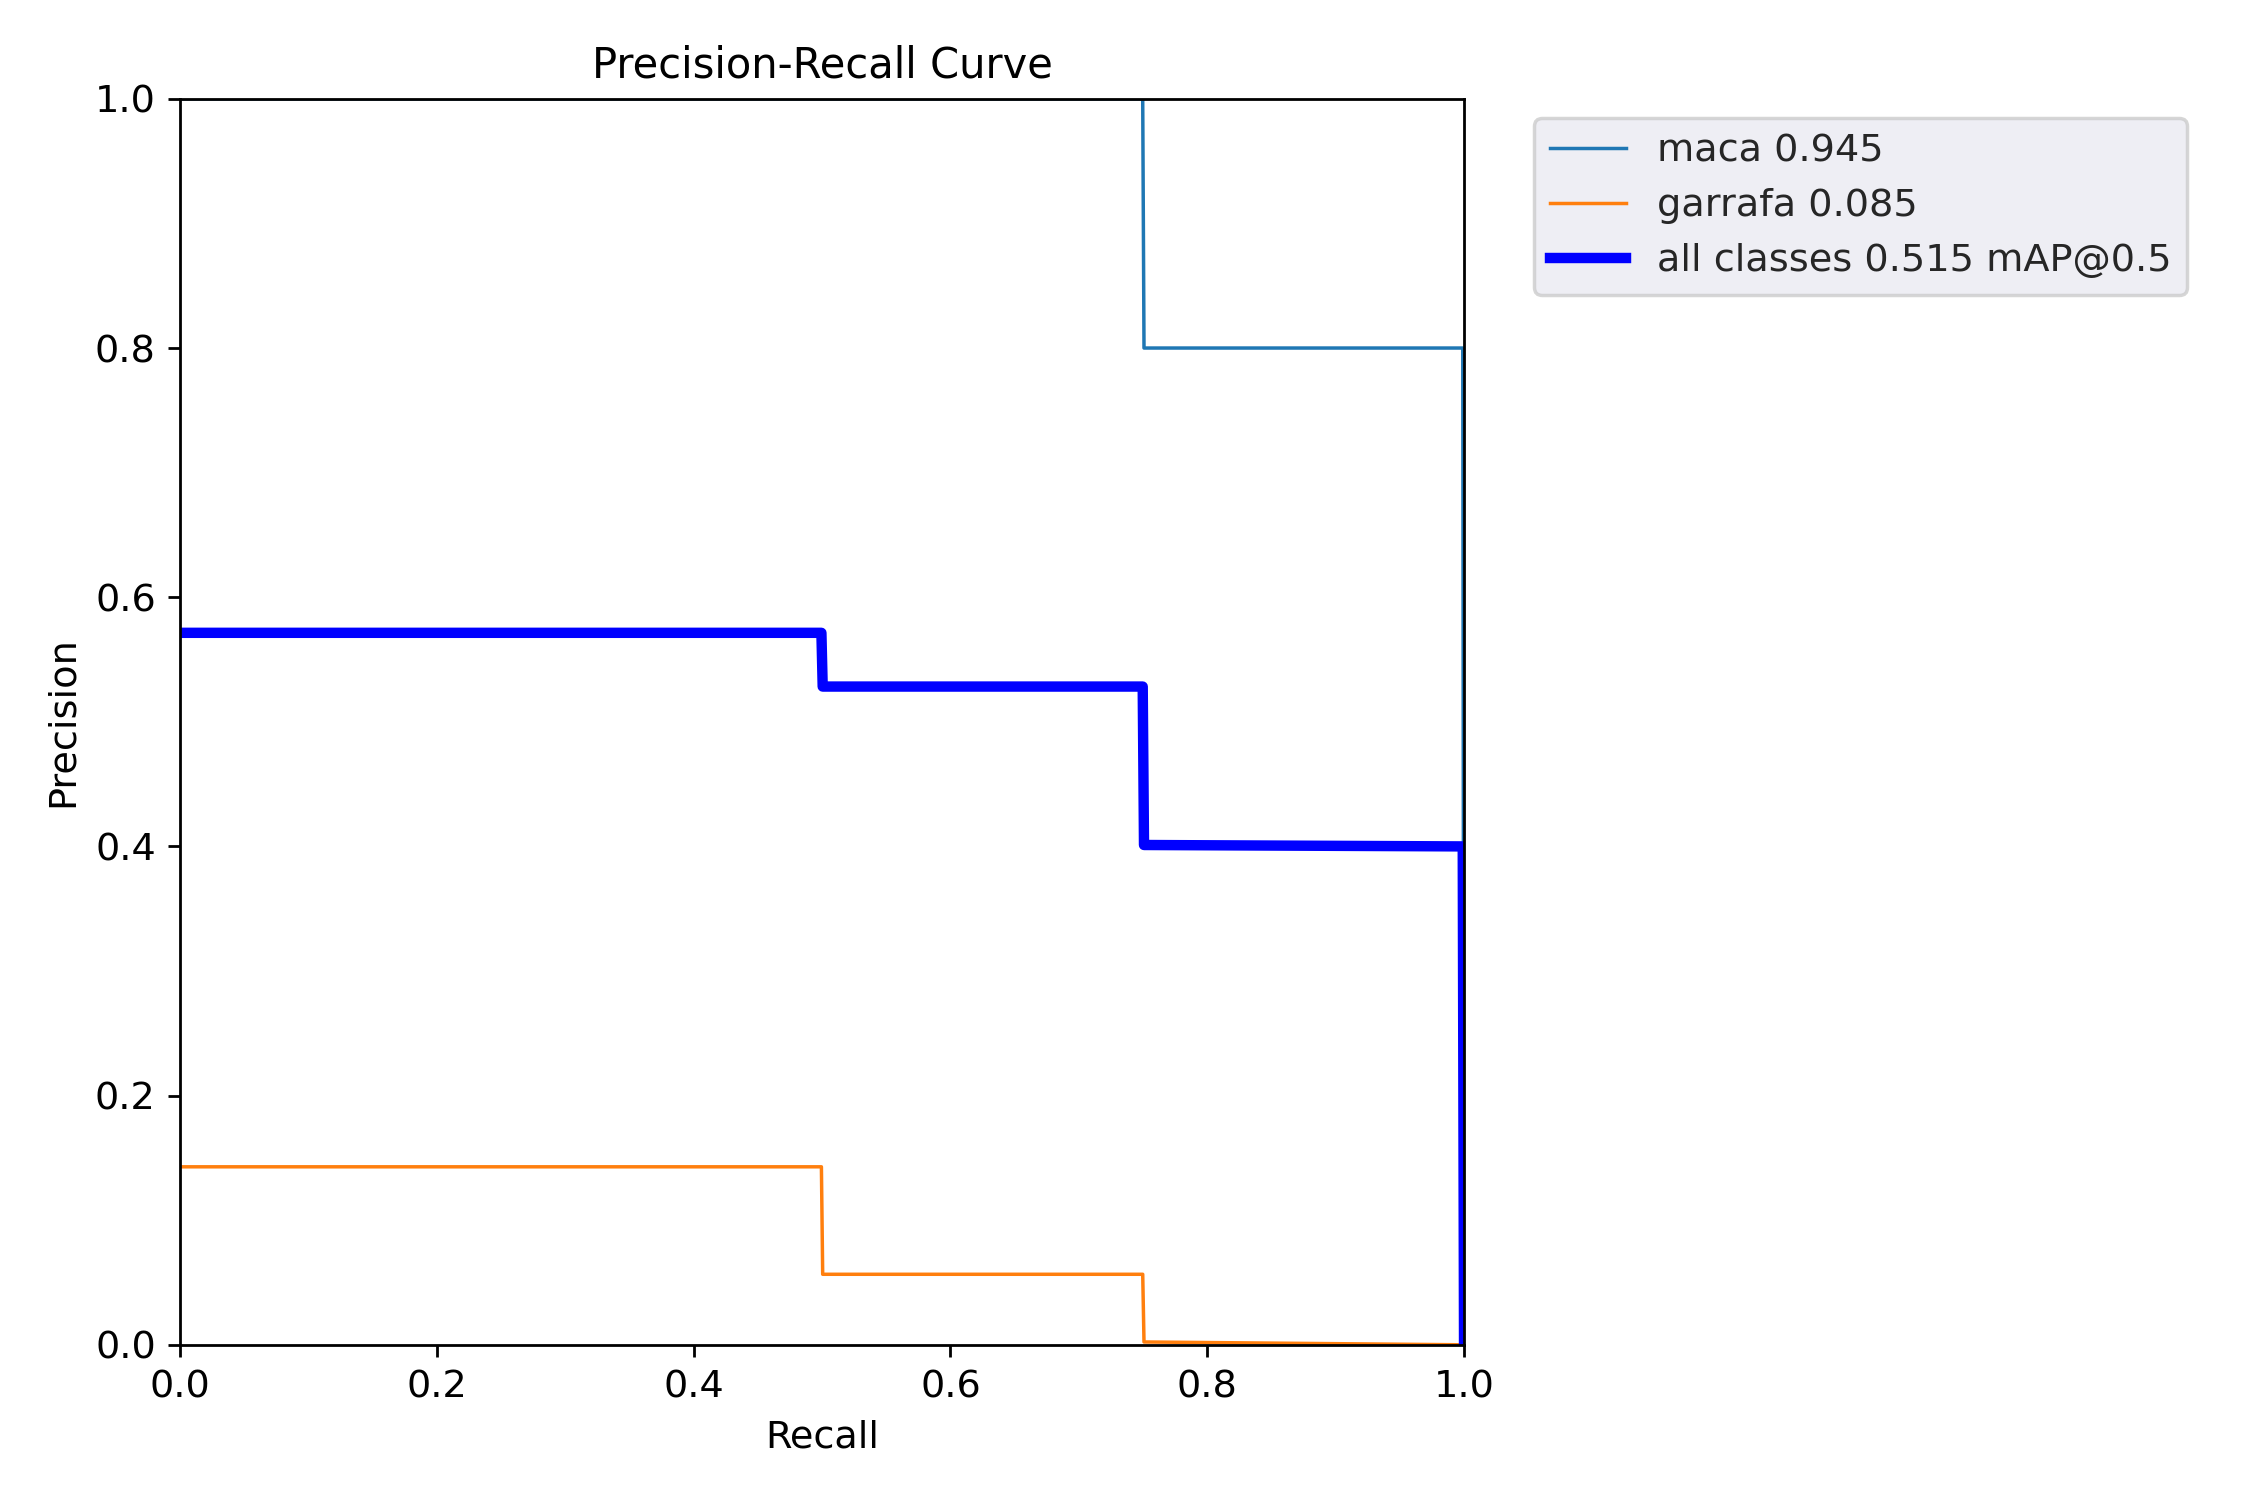

In [37]:
print('=== Curva Precision-Recall - 30 Épocas ===')
display(Image(filename='runs/train/treino_30ep5/PR_curve.png', width=600))

## 5. Treinamento - Simulação 2 (60 Épocas)

Agora realizamos o segundo treinamento com **60 épocas**, mantendo os mesmos hiperparâmetros para uma comparação justa.

In [40]:
!python train.py --img 640 --batch 16 --epochs 60 --data dataset.yaml --weights yolov5s.pt --name treino_60ep

wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-04-27 22:33:01.807837: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777329182.093782   65390 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777329182.182817   65390 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777329182.776102   65390 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777329182.776172   65390 computation_placer.cc:177] computation placer already registere

### 5.1 Resultados do Treinamento com 60 Épocas

=== Métricas de Treinamento - 60 Épocas ===


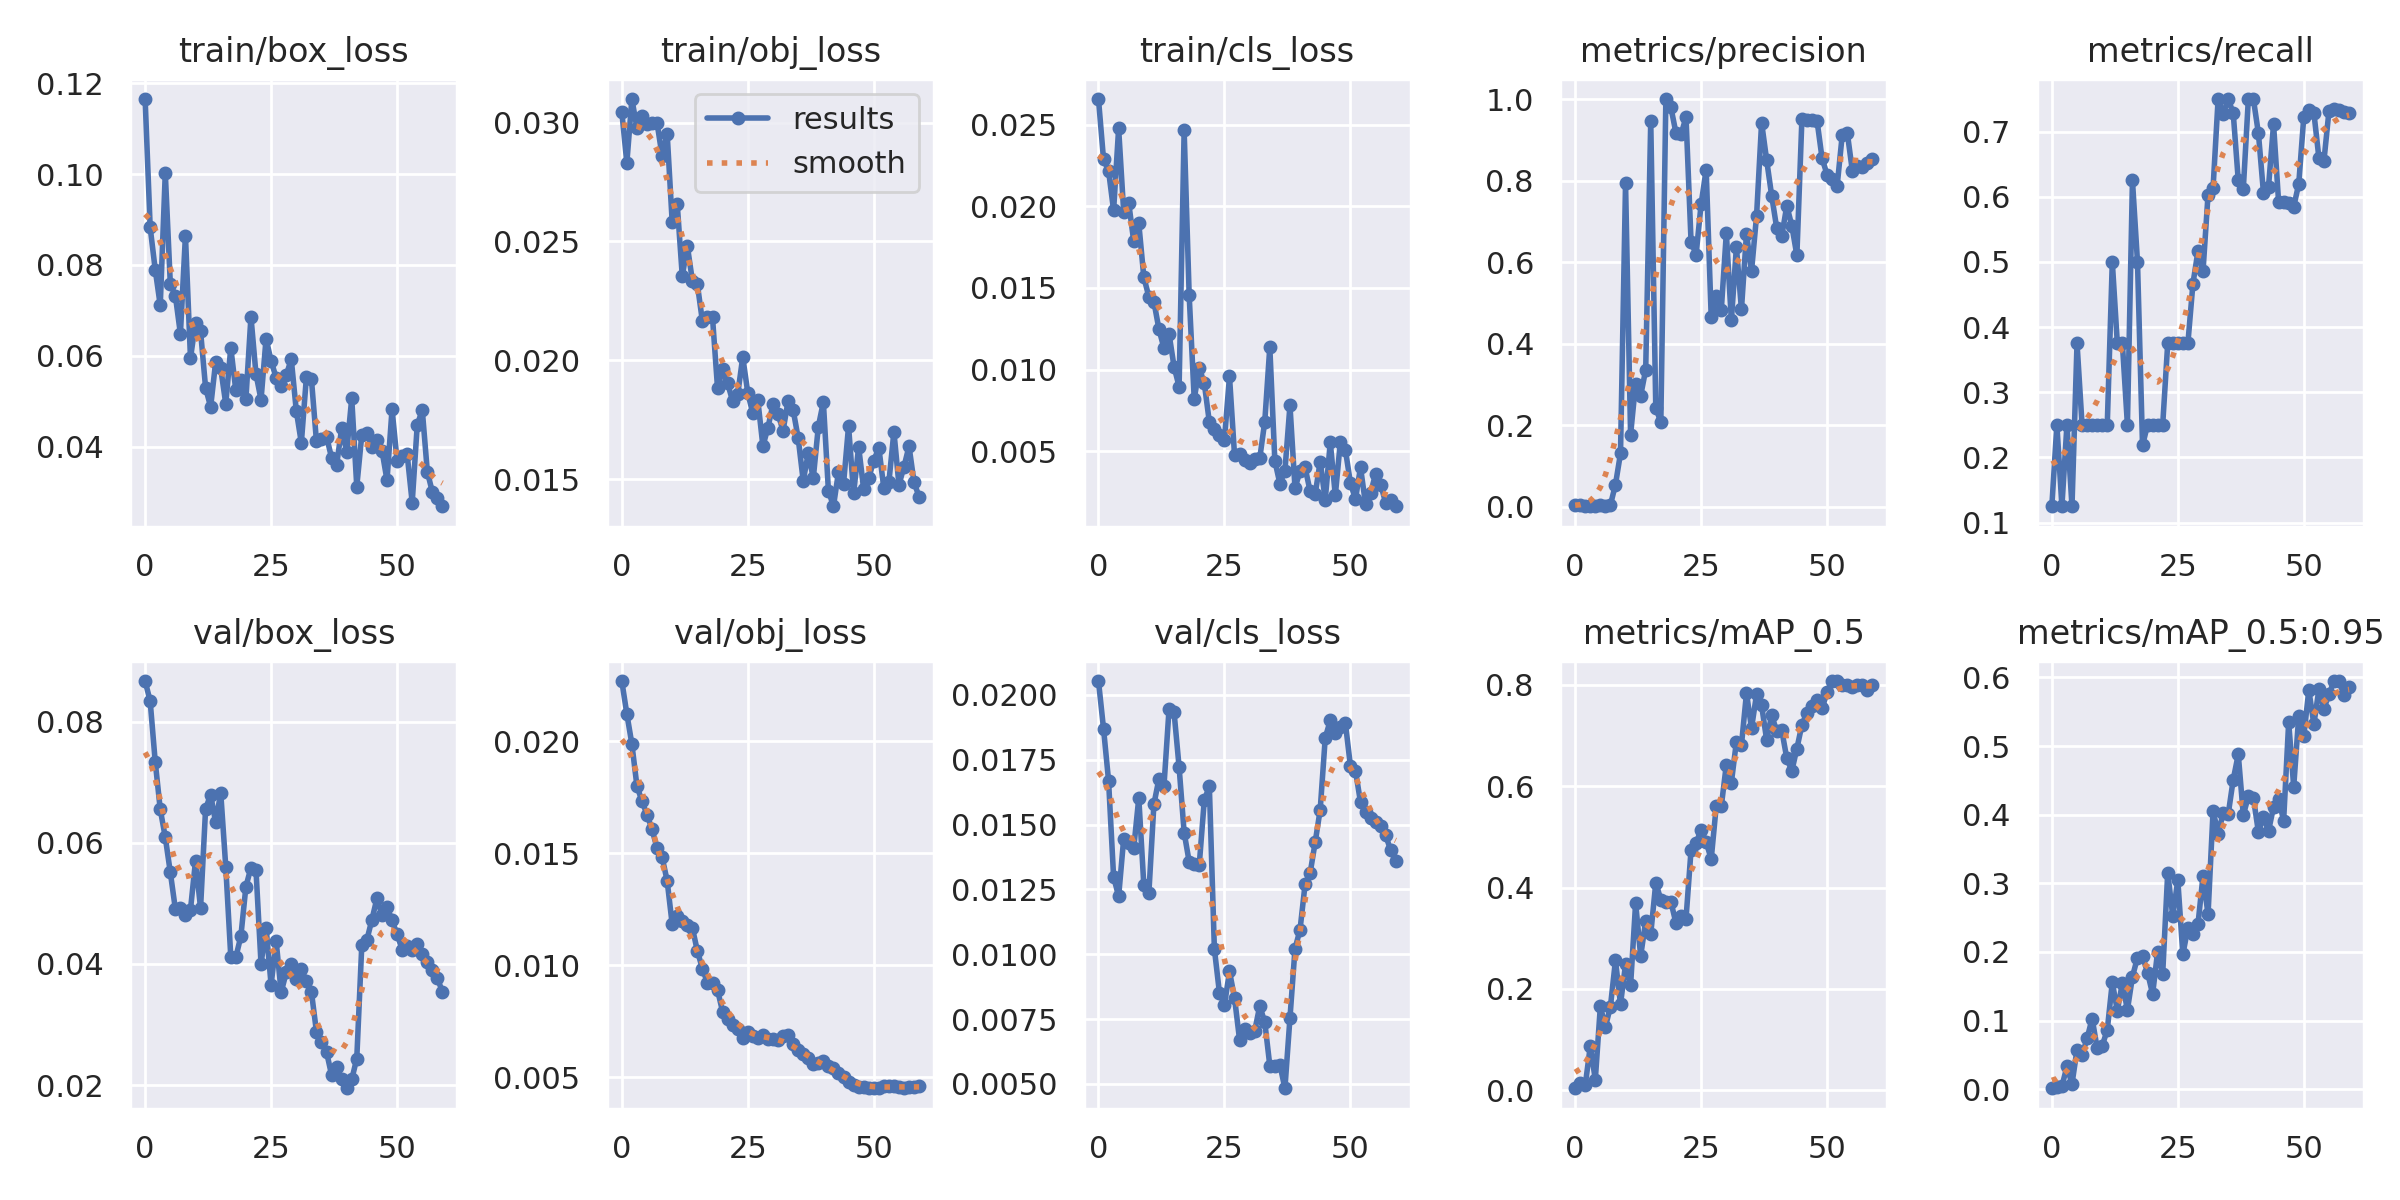

In [45]:
print('=== Métricas de Treinamento - 60 Épocas ===')
# Updated path to the correct run directory found via os.listdir
display(Image(filename='runs/train/treino_60ep2/results.png', width=800))

=== Matriz de Confusão - 60 Épocas ===


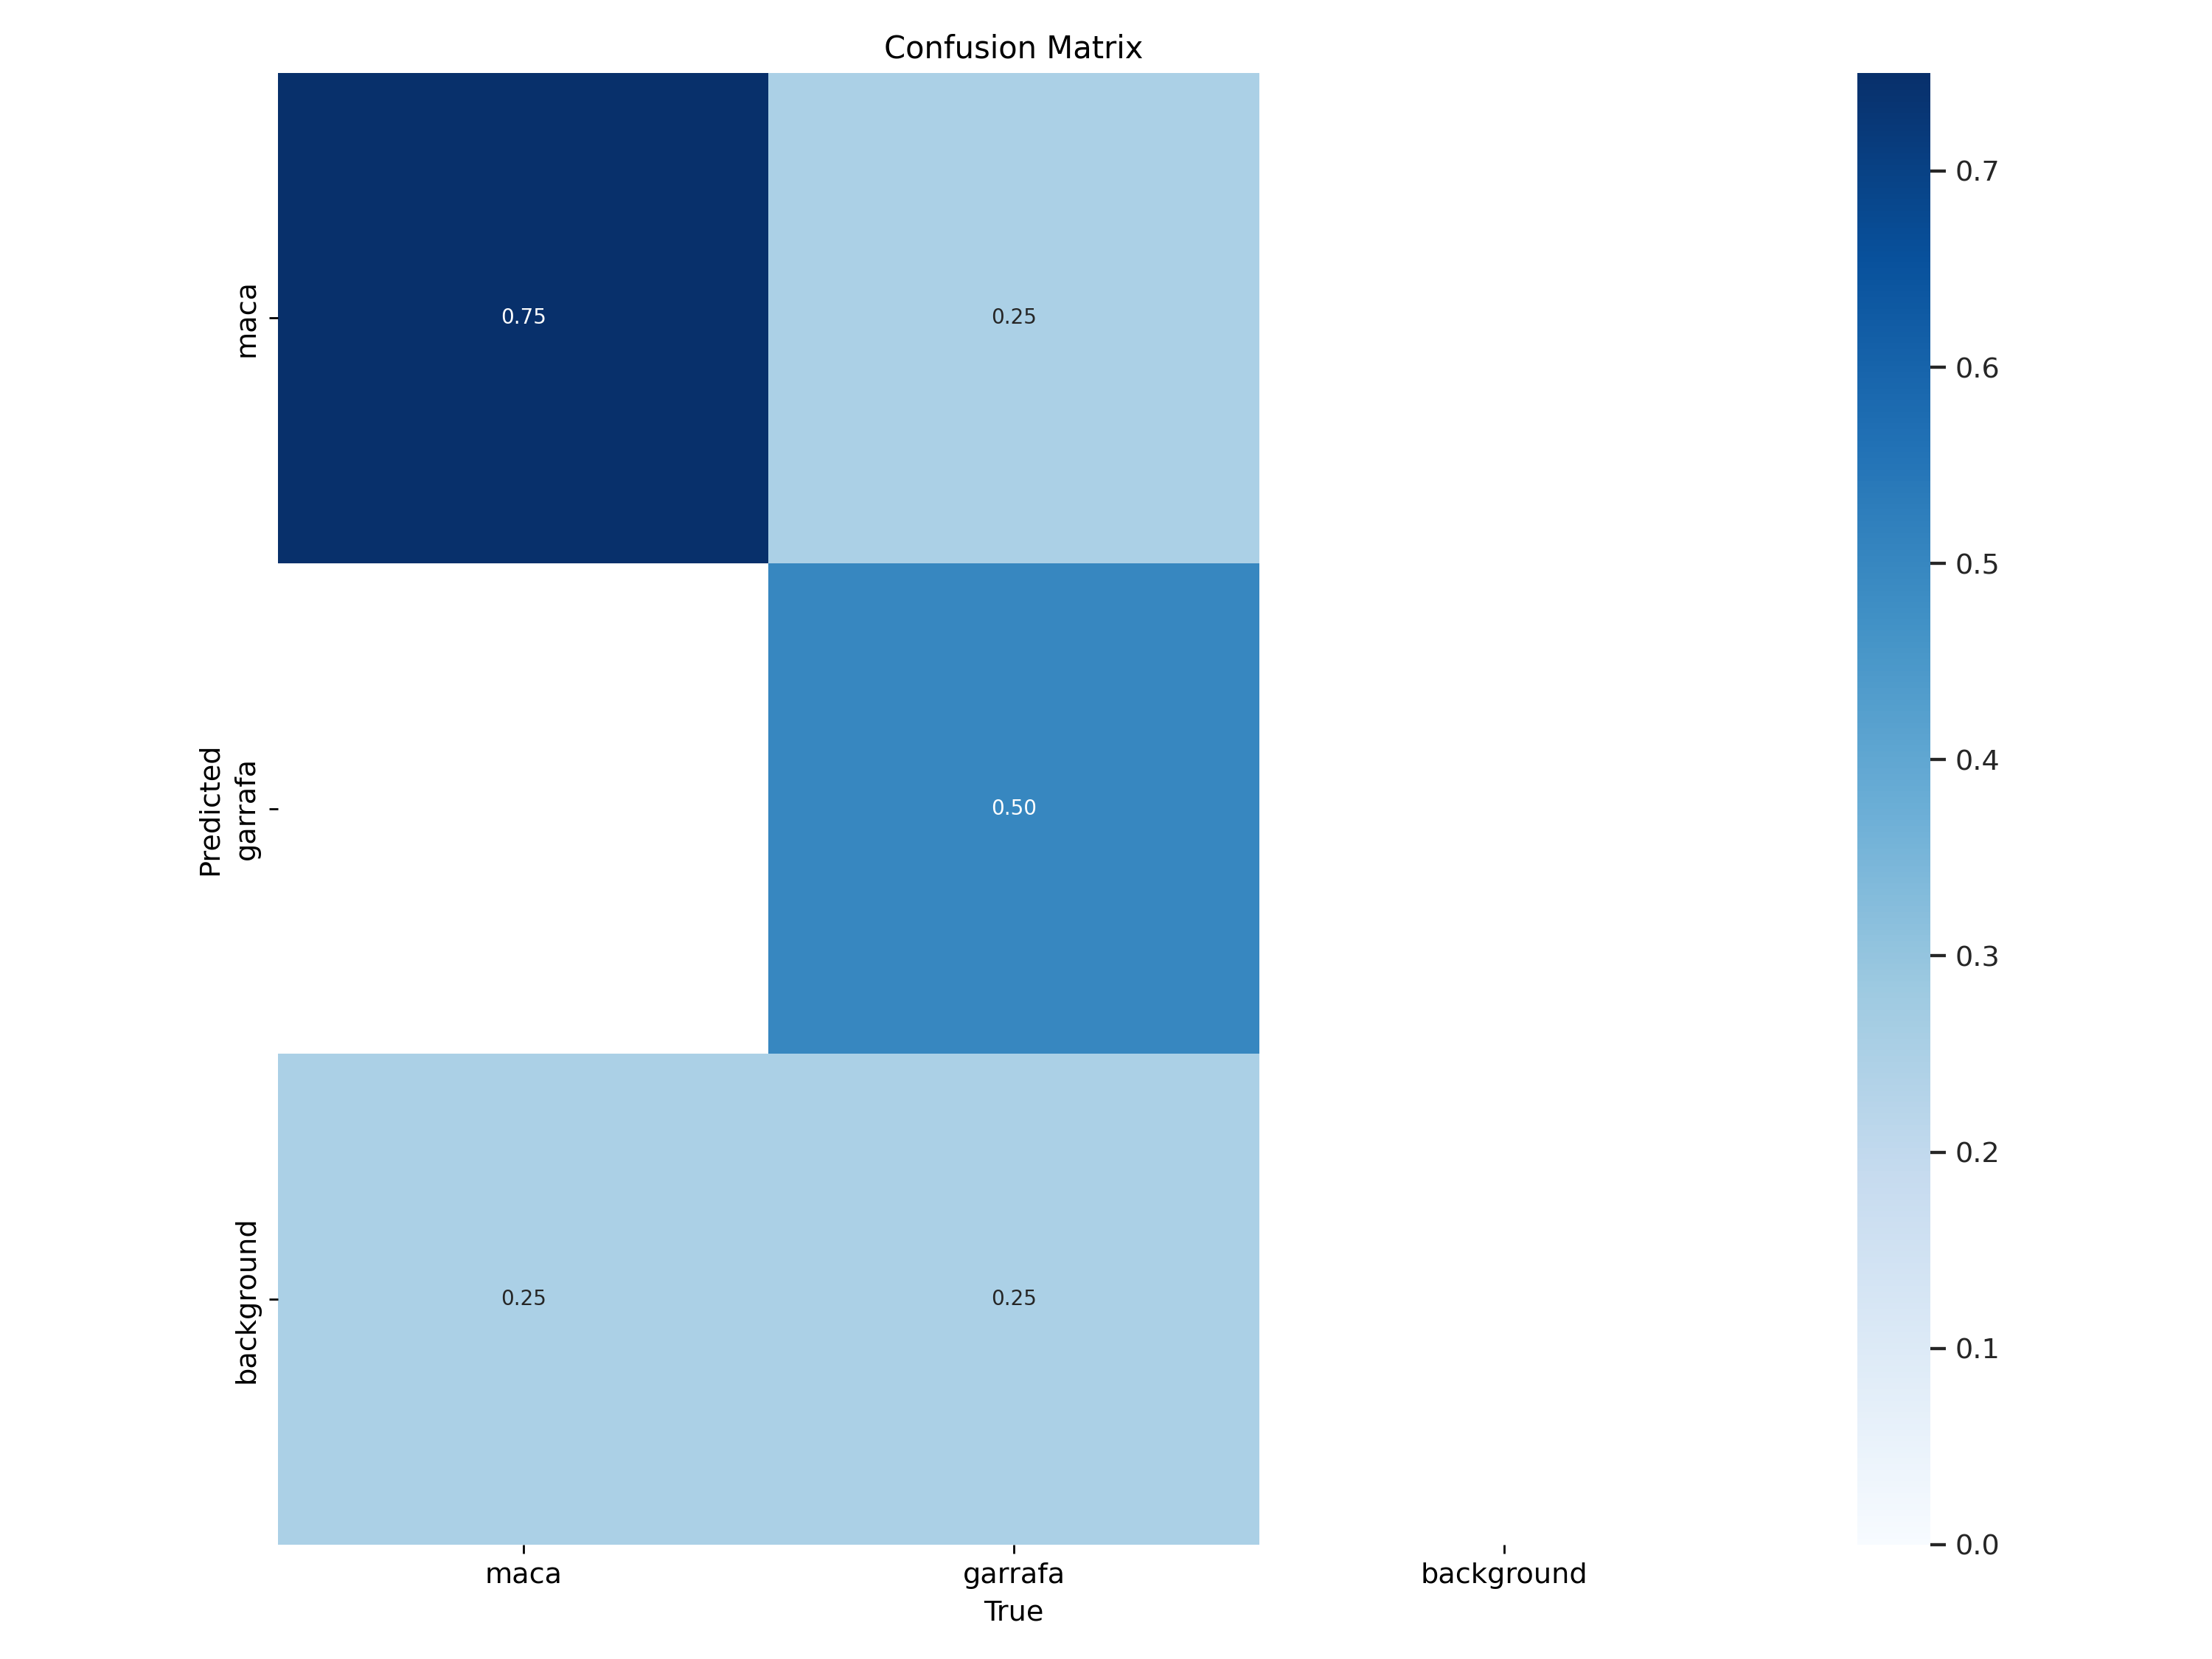

In [47]:
print('=== Matriz de Confusão - 60 Épocas ===')
display(Image(filename='runs/train/treino_60ep2/confusion_matrix.png', width=600))

=== Curva F1 - 60 Épocas ===


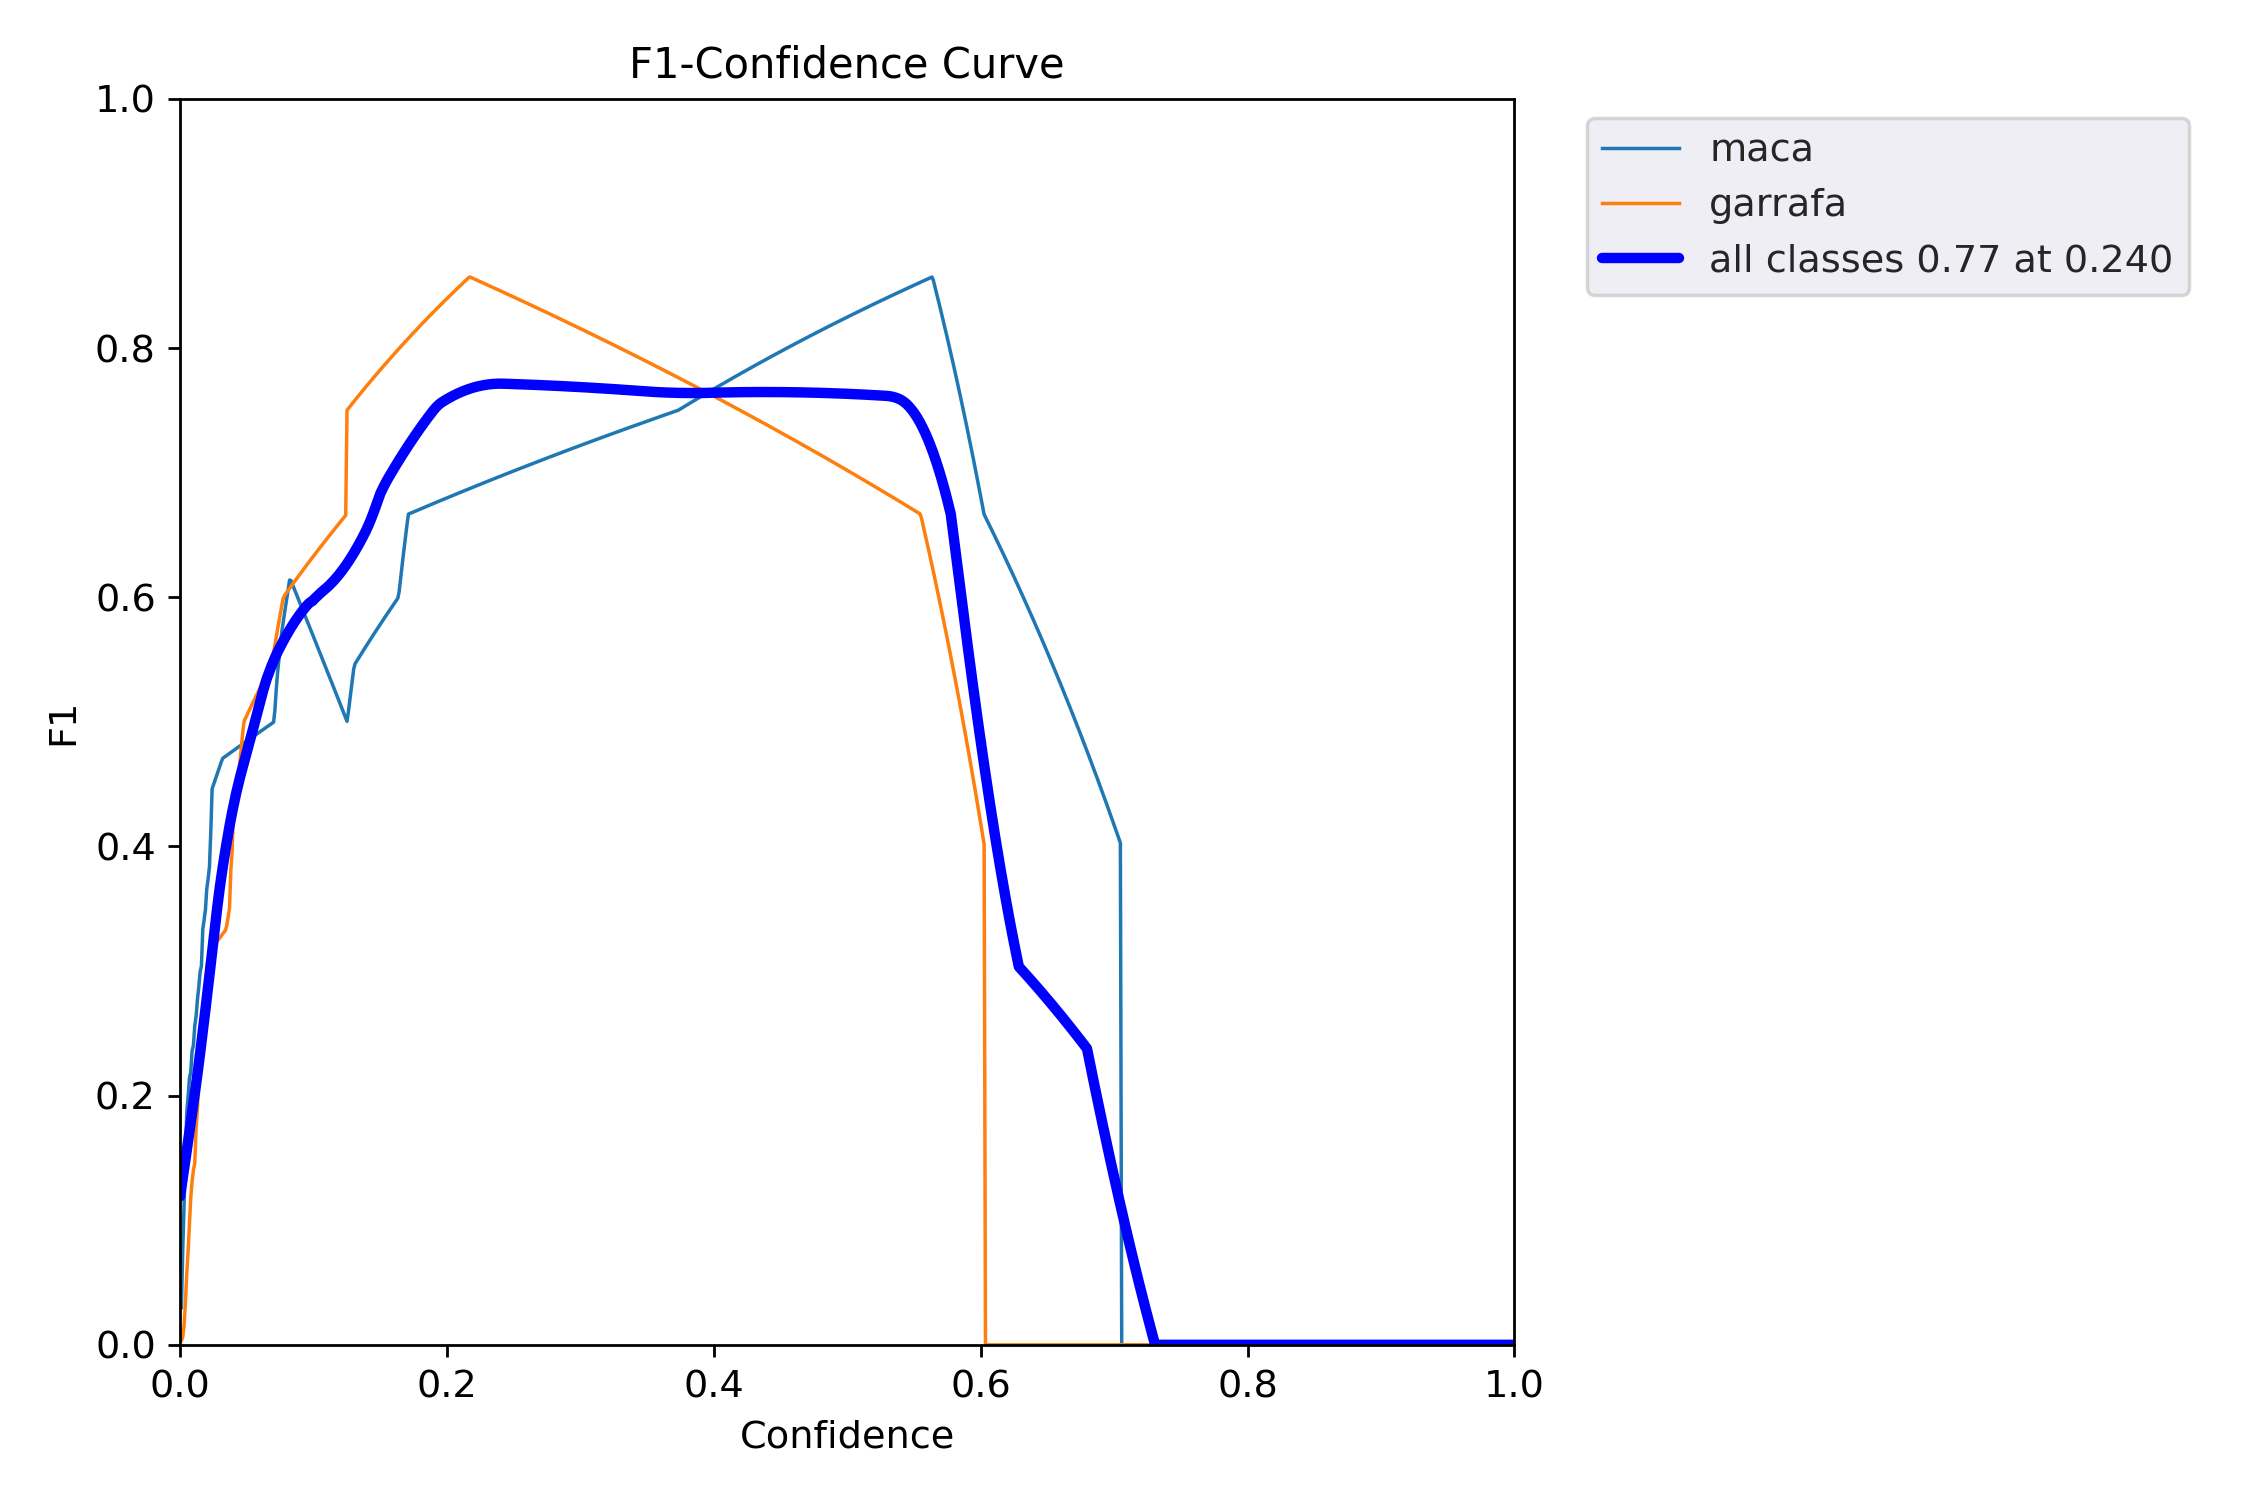

In [48]:
print('=== Curva F1 - 60 Épocas ===')
display(Image(filename='runs/train/treino_60ep2/F1_curve.png', width=600))

=== Curva Precision-Recall - 60 Épocas ===


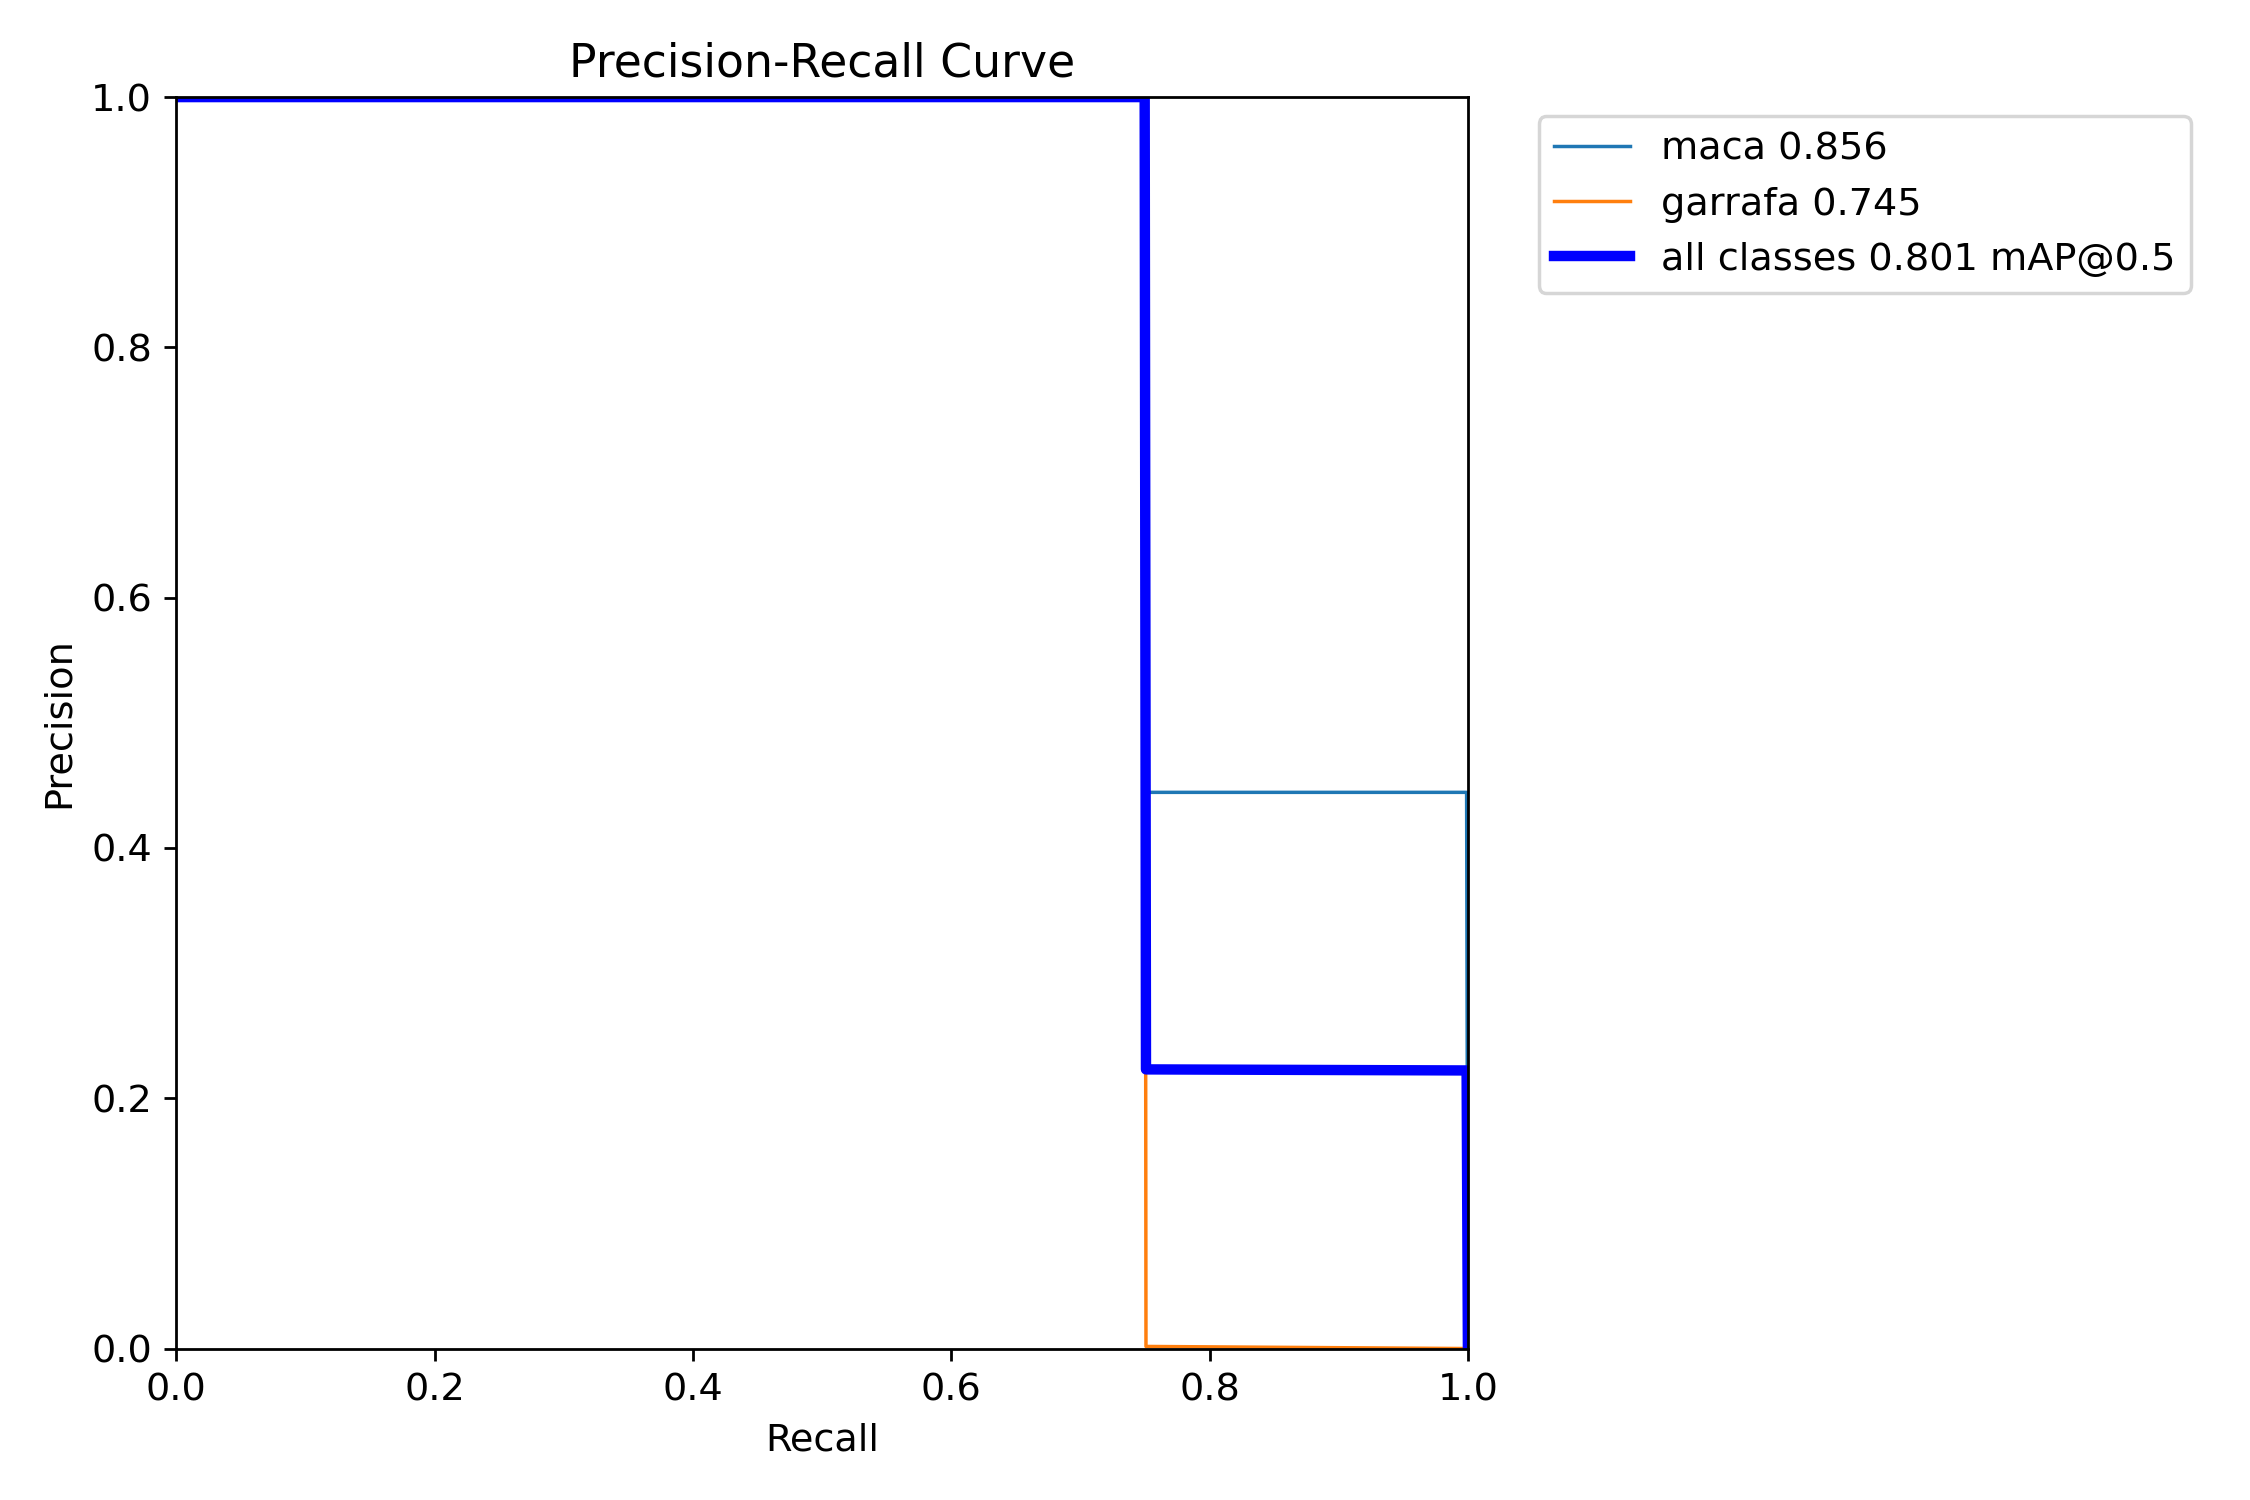

In [49]:
print('=== Curva Precision-Recall - 60 Épocas ===')
display(Image(filename='runs/train/treino_60ep2/PR_curve.png', width=600))

## 6. Comparação entre as Simulações (30 vs 60 Épocas)

Nesta seção, comparamos os resultados das duas simulações para avaliar o impacto do número de épocas.

In [50]:
import pandas as pd

# Using the identified correct paths for 30 and 60 epochs
results_30 = pd.read_csv('runs/train/treino_30ep5/results.csv')
results_30.columns = results_30.columns.str.strip()

results_60 = pd.read_csv('runs/train/treino_60ep2/results.csv')
results_60.columns = results_60.columns.str.strip()

print('=== Melhores Métricas - 30 Épocas ===')
print(f"mAP@0.5:      {results_30['metrics/mAP_0.5'].max():.4f}")
print(f"mAP@0.5:0.95:  {results_30['metrics/mAP_0.5:0.95'].max():.4f}")
print(f"Precision:      {results_30['metrics/precision'].max():.4f}")
print(f"Recall:         {results_30['metrics/recall'].max():.4f}")
print(f"Box Loss final: {results_30['train/box_loss'].iloc[-1]:.4f}")

print()

print('=== Melhores Métricas - 60 Épocas ===')
print(f"mAP@0.5:      {results_60['metrics/mAP_0.5'].max():.4f}")
print(f"mAP@0.5:0.95:  {results_60['metrics/mAP_0.5:0.95'].max():.4f}")
print(f"Precision:      {results_60['metrics/precision'].max():.4f}")
print(f"Recall:         {results_60['metrics/recall'].max():.4f}")
print(f"Box Loss final: {results_60['train/box_loss'].iloc[-1]:.4f}")

=== Melhores Métricas - 30 Épocas ===
mAP@0.5:      0.5969
mAP@0.5:0.95:  0.3402
Precision:      0.8875
Recall:         0.6250
Box Loss final: 0.0480

=== Melhores Métricas - 60 Épocas ===
mAP@0.5:      0.8076
mAP@0.5:0.95:  0.5947
Precision:      1.0000
Recall:         0.7500
Box Loss final: 0.0269


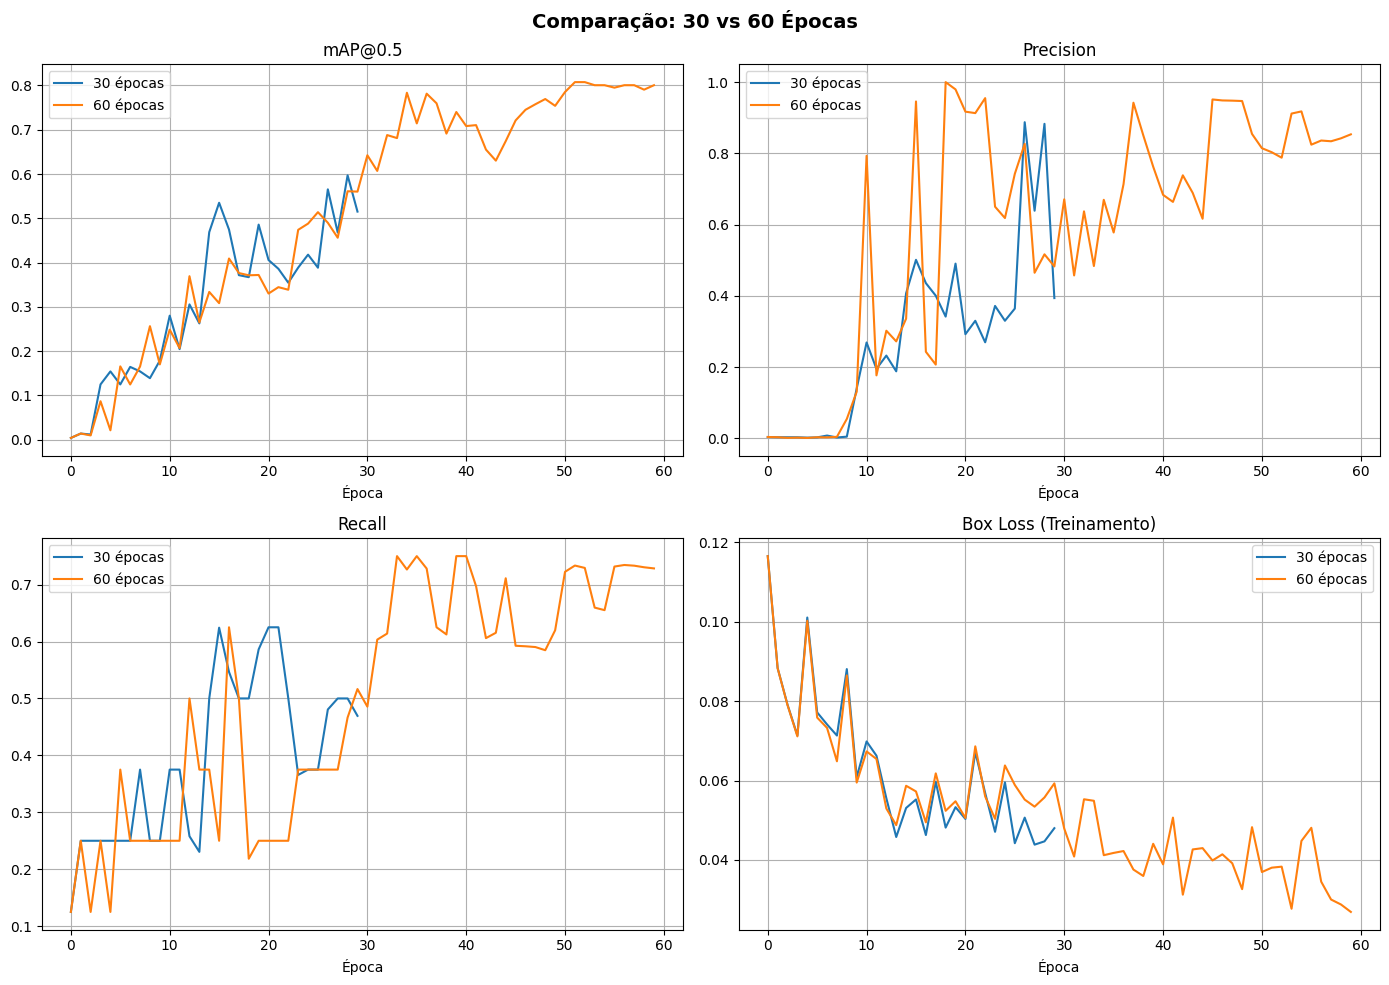

In [51]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0][0].plot(results_30['metrics/mAP_0.5'], label='30 épocas')
axes[0][0].plot(results_60['metrics/mAP_0.5'], label='60 épocas')
axes[0][0].set_title('mAP@0.5')
axes[0][0].set_xlabel('Época')
axes[0][0].legend()
axes[0][0].grid(True)

axes[0][1].plot(results_30['metrics/precision'], label='30 épocas')
axes[0][1].plot(results_60['metrics/precision'], label='60 épocas')
axes[0][1].set_title('Precision')
axes[0][1].set_xlabel('Época')
axes[0][1].legend()
axes[0][1].grid(True)

axes[1][0].plot(results_30['metrics/recall'], label='30 épocas')
axes[1][0].plot(results_60['metrics/recall'], label='60 épocas')
axes[1][0].set_title('Recall')
axes[1][0].set_xlabel('Época')
axes[1][0].legend()
axes[1][0].grid(True)

axes[1][1].plot(results_30['train/box_loss'], label='30 épocas')
axes[1][1].plot(results_60['train/box_loss'], label='60 épocas')
axes[1][1].set_title('Box Loss (Treinamento)')
axes[1][1].set_xlabel('Época')
axes[1][1].legend()
axes[1][1].grid(True)

plt.suptitle('Comparação: 30 vs 60 Épocas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Validação

Executamos a validação com os pesos do melhor modelo de cada treinamento para obter métricas detalhadas.

In [53]:
print('=== Validação - Modelo 30 Épocas ===')
!python val.py --weights runs/train/treino_30ep5/weights/best.pt --data dataset.yaml --img 640 --name val_30ep

=== Validação - Modelo 30 Épocas ===
val: data=dataset.yaml, weights=['runs/train/treino_30ep5/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=val_30ep, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-476-g66554d2f Python-3.12.13 torch-2.10.0+cpu CPU

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
val: Scanning /content/drive/MyDrive/dataset_yolo/val/labels.cache... 8 images, 0 backgrounds, 0 corrupt: 100% 8/8 [00:00<?, ?it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% 1/1 [00:08<00:00,  8.86s/it]
                   all          8          8      0.394      0.469      0.515       0.34
                  maca          8          4      0.787      0.937      0.945      0.651
       

In [54]:
print('=== Validação - Modelo 60 Épocas ===')
!python val.py --weights runs/train/treino_60ep2/weights/best.pt --data dataset.yaml --img 640 --name val_60ep

=== Validação - Modelo 60 Épocas ===
val: data=dataset.yaml, weights=['runs/train/treino_60ep2/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=runs/val, name=val_60ep, exist_ok=False, half=False, dnn=False
YOLOv5 🚀 v7.0-476-g66554d2f Python-3.12.13 torch-2.10.0+cpu CPU

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
val: Scanning /content/drive/MyDrive/dataset_yolo/val/labels.cache... 8 images, 0 backgrounds, 0 corrupt: 100% 8/8 [00:00<?, ?it/s]
                 Class     Images  Instances          P          R      mAP50   mAP50-95: 100% 1/1 [00:04<00:00,  4.68s/it]
                   all          8          8      0.833      0.734      0.801      0.595
                  maca          8          4      0.667       0.75      0.856      0.677
       

## 8. Testes com Imagens Inéditas

Agora testamos os modelos com as 8 imagens de teste (4 maçãs + 4 garrafas) que **não foram usadas no treinamento nem na validação**.  
Isso demonstra a capacidade de generalização do modelo.

In [55]:
print('=== Teste - Modelo 30 Épocas ===')
!python detect.py --weights runs/train/treino_30ep5/weights/best.pt --source '{DRIVE_DATASET}/test/images' --img 640 --conf 0.25 --name teste_30ep --save-txt --save-conf

=== Teste - Modelo 30 Épocas ===
detect: weights=['runs/train/treino_30ep5/weights/best.pt'], source=/content/drive/MyDrive/dataset_yolo/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_format=0, save_csv=False, save_conf=True, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=teste_30ep, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-476-g66554d2f Python-3.12.13 torch-2.10.0+cpu CPU

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
image 1/8 /content/drive/MyDrive/dataset_yolo/test/images/garrafa_036.jpeg: 640x448 (no detections), 259.8ms
image 2/8 /content/drive/MyDrive/dataset_yolo/test/images/garrafa_037.jpg: 640x640 (no detections), 372.4ms
image 3/8 /content/drive/MyDrive/dataset_yolo/t

In [56]:
print('=== Teste - Modelo 60 Épocas ===')
!python detect.py --weights runs/train/treino_60ep2/weights/best.pt --source '{DRIVE_DATASET}/test/images' --img 640 --conf 0.25 --name teste_60ep --save-txt --save-conf

=== Teste - Modelo 60 Épocas ===
detect: weights=['runs/train/treino_60ep2/weights/best.pt'], source=/content/drive/MyDrive/dataset_yolo/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_format=0, save_csv=False, save_conf=True, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=teste_60ep, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-476-g66554d2f Python-3.12.13 torch-2.10.0+cpu CPU

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
image 1/8 /content/drive/MyDrive/dataset_yolo/test/images/garrafa_036.jpeg: 640x448 (no detections), 278.3ms
image 2/8 /content/drive/MyDrive/dataset_yolo/test/images/garrafa_037.jpg: 640x640 (no detections), 354.2ms
image 3/8 /content/drive/MyDrive/dataset_yolo/t

### 8.1 Visualização dos Resultados dos Testes

Abaixo estão as imagens de teste processadas pelo modelo, mostrando as detecções com bounding boxes e confiança.

  RESULTADOS DO TESTE - 30 ÉPOCAS

garrafa_036.jpeg


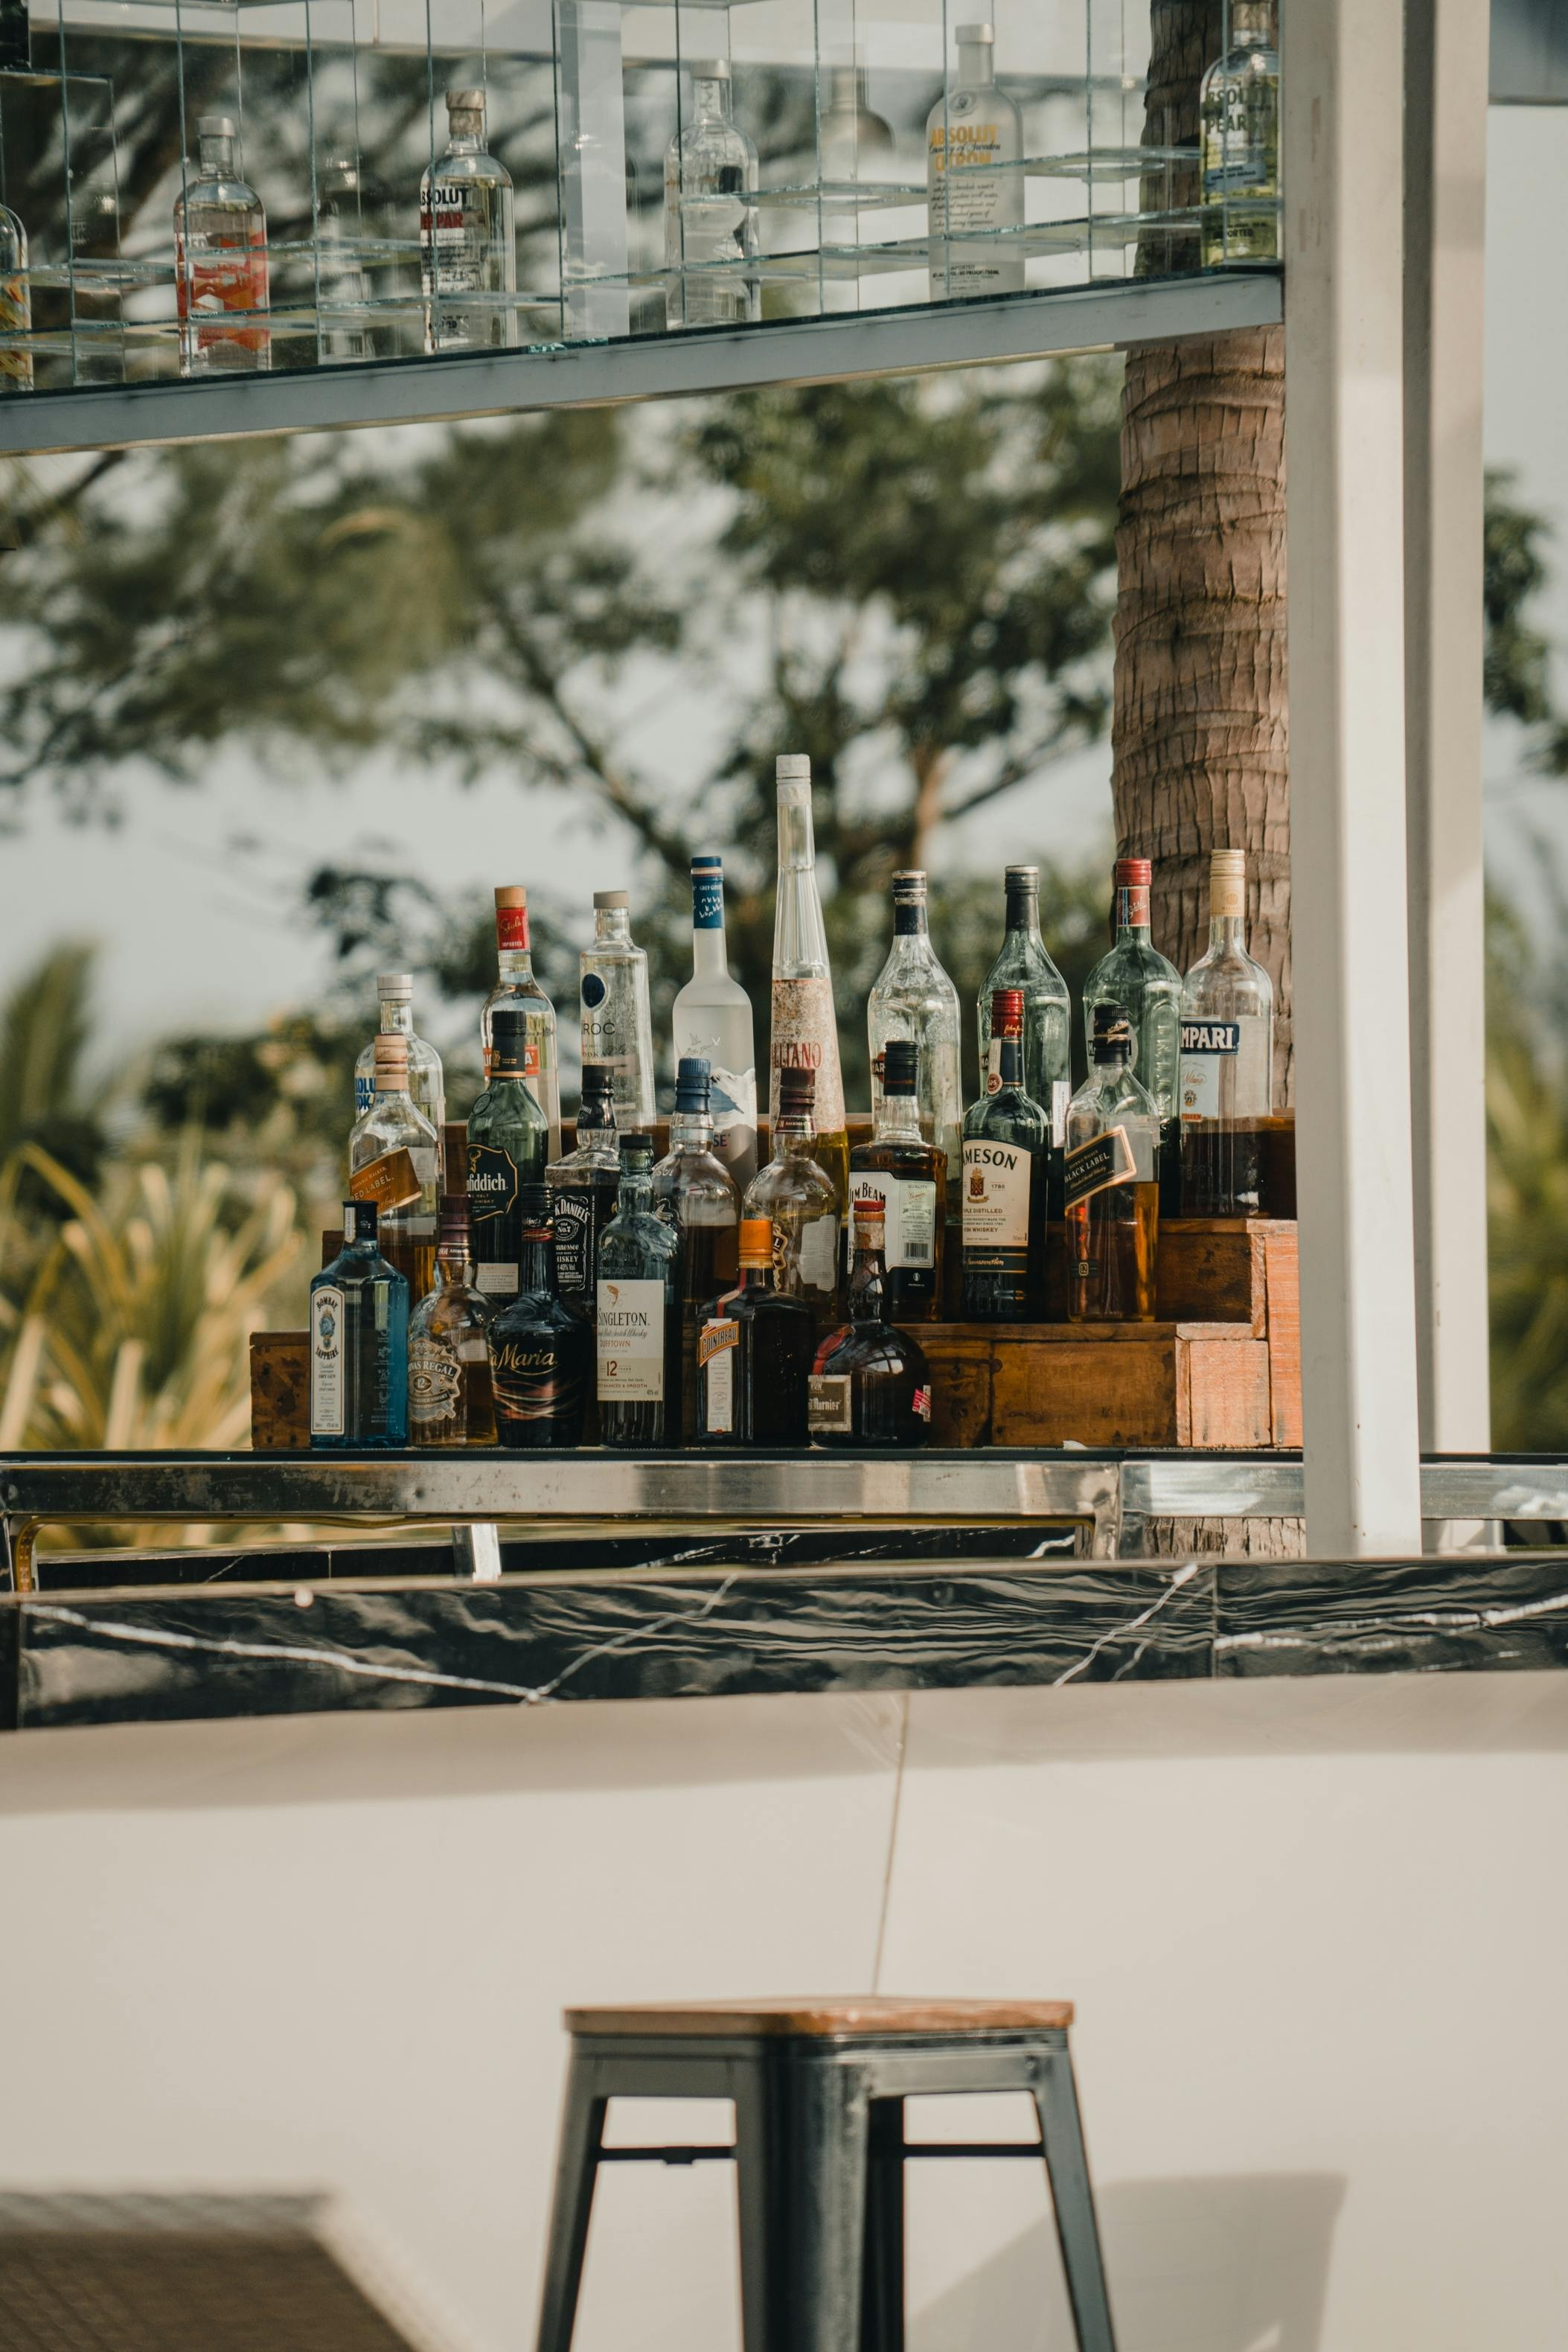


garrafa_037.jpg


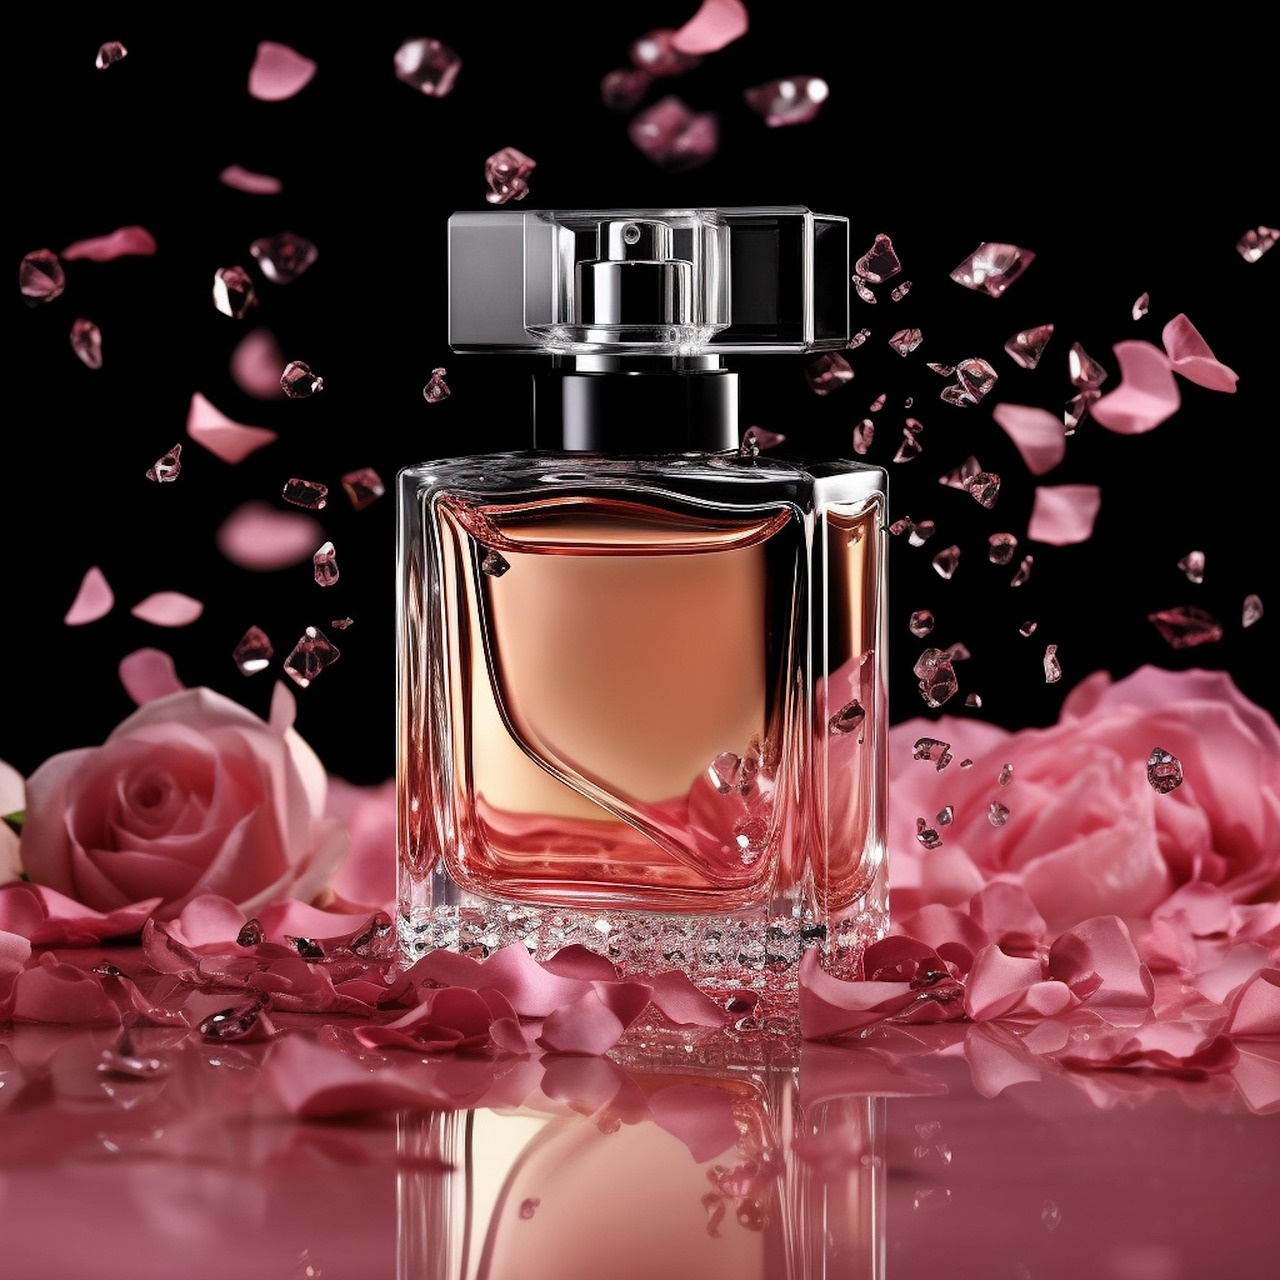


garrafa_038.jpg


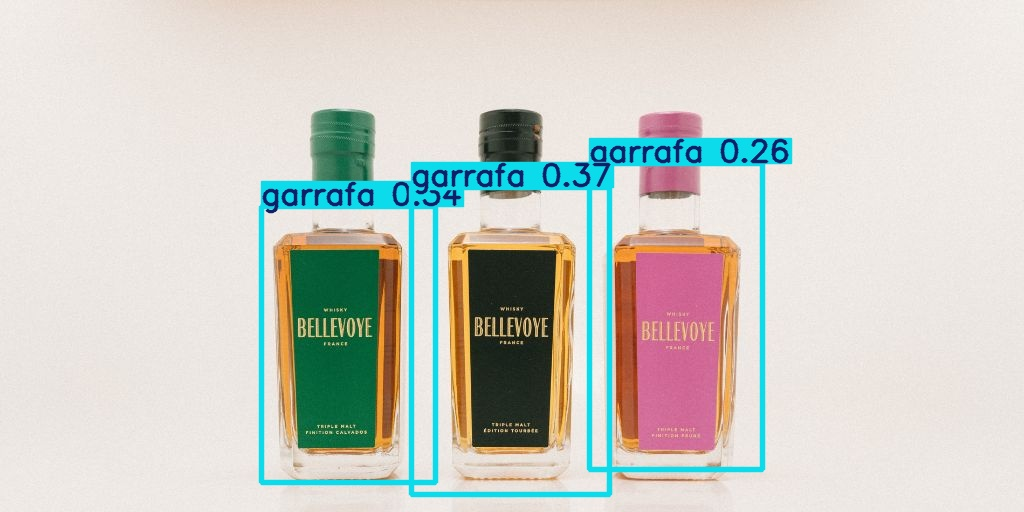


garrafa_039.jpg


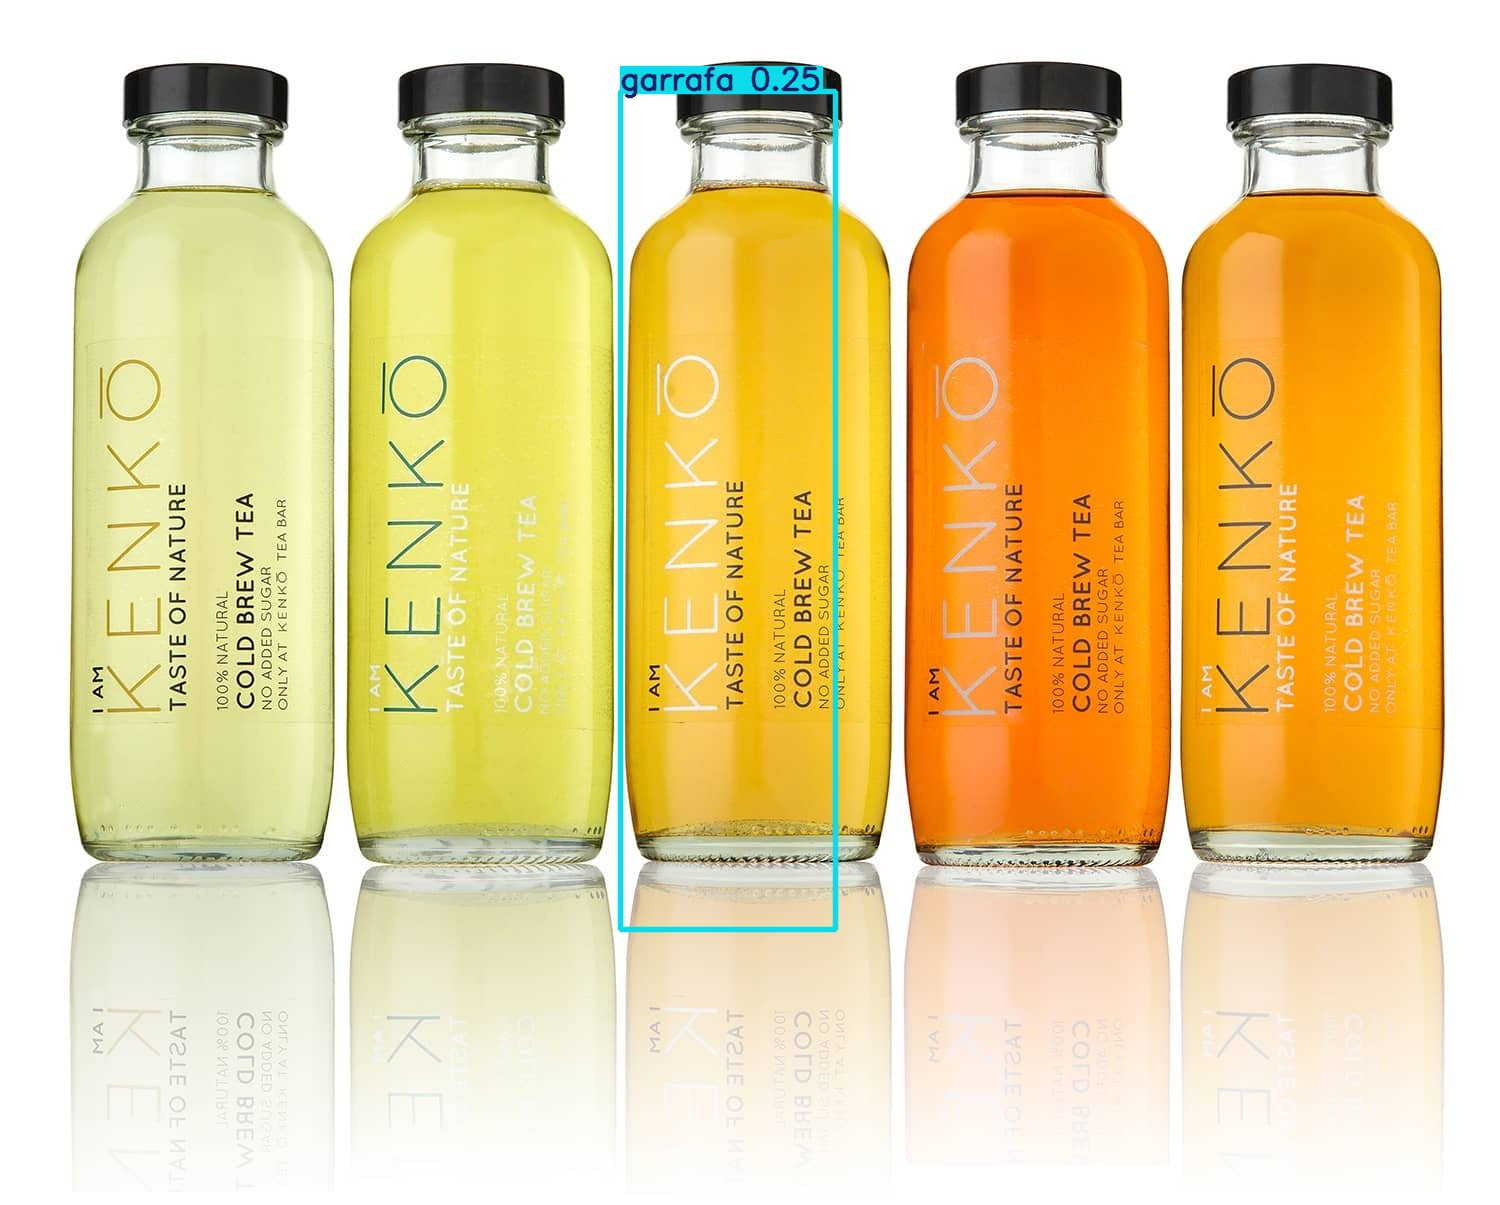


maca_036.jpg


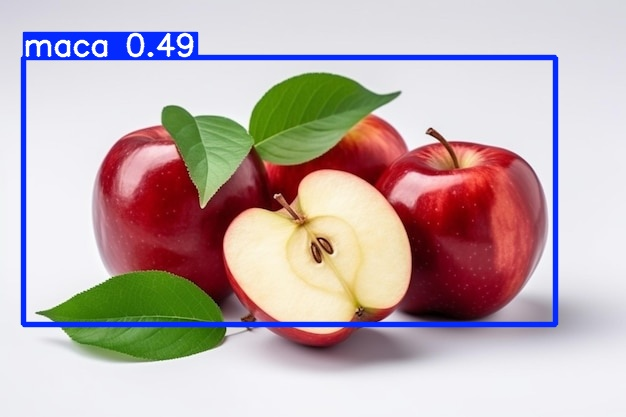


maca_037.jpg


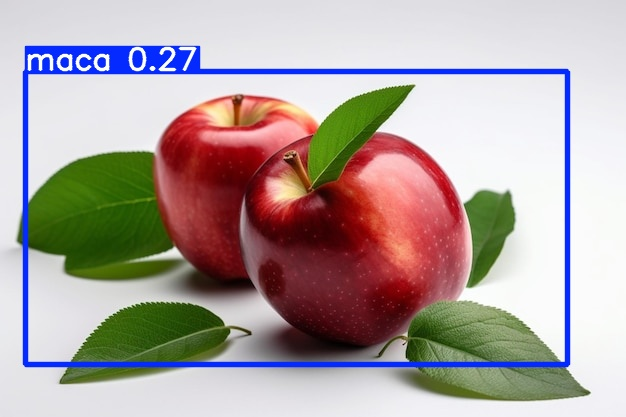


maca_038.jpg


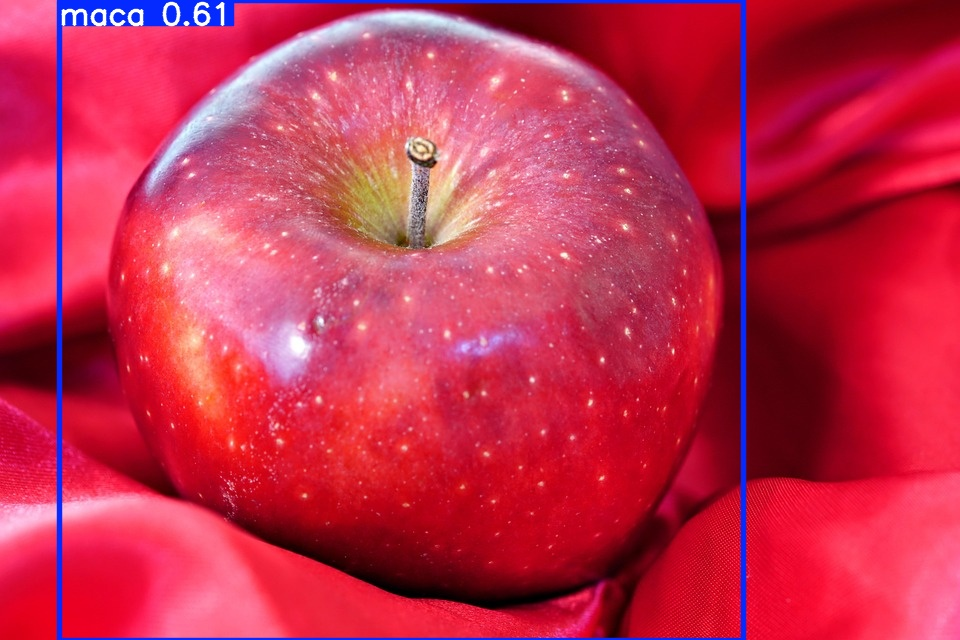


maca_039.jpg


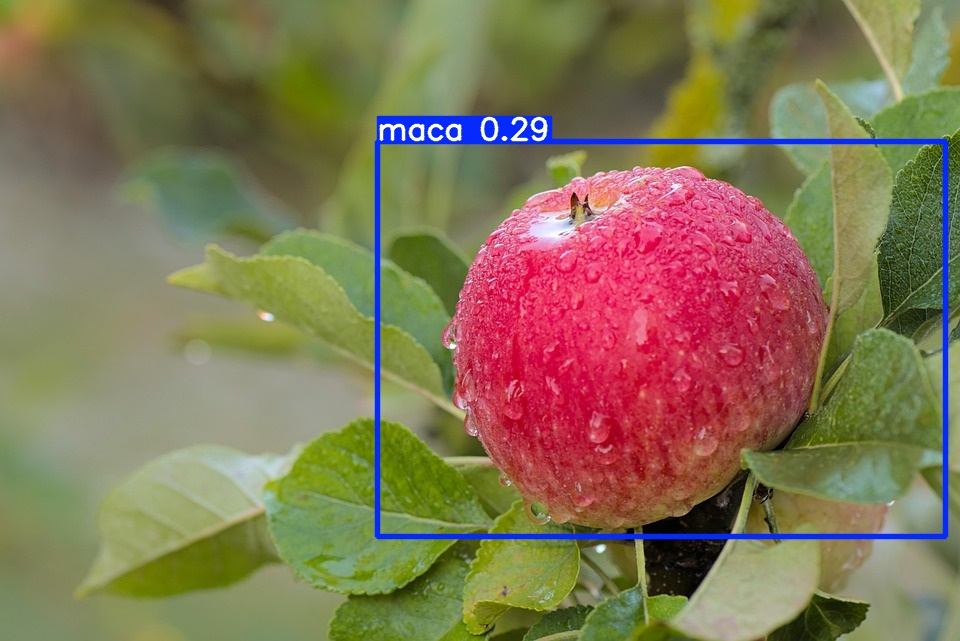

In [57]:
import glob

print('=========================================')
print('  RESULTADOS DO TESTE - 30 ÉPOCAS')
print('=========================================')
test_imgs_30 = sorted(glob.glob('runs/detect/teste_30ep/*.jpg') + glob.glob('runs/detect/teste_30ep/*.jpeg') + glob.glob('runs/detect/teste_30ep/*.png'))
for img_path in test_imgs_30:
    print(f'\n{os.path.basename(img_path)}')
    display(Image(filename=img_path, width=500))

  RESULTADOS DO TESTE - 60 ÉPOCAS

garrafa_036.jpeg


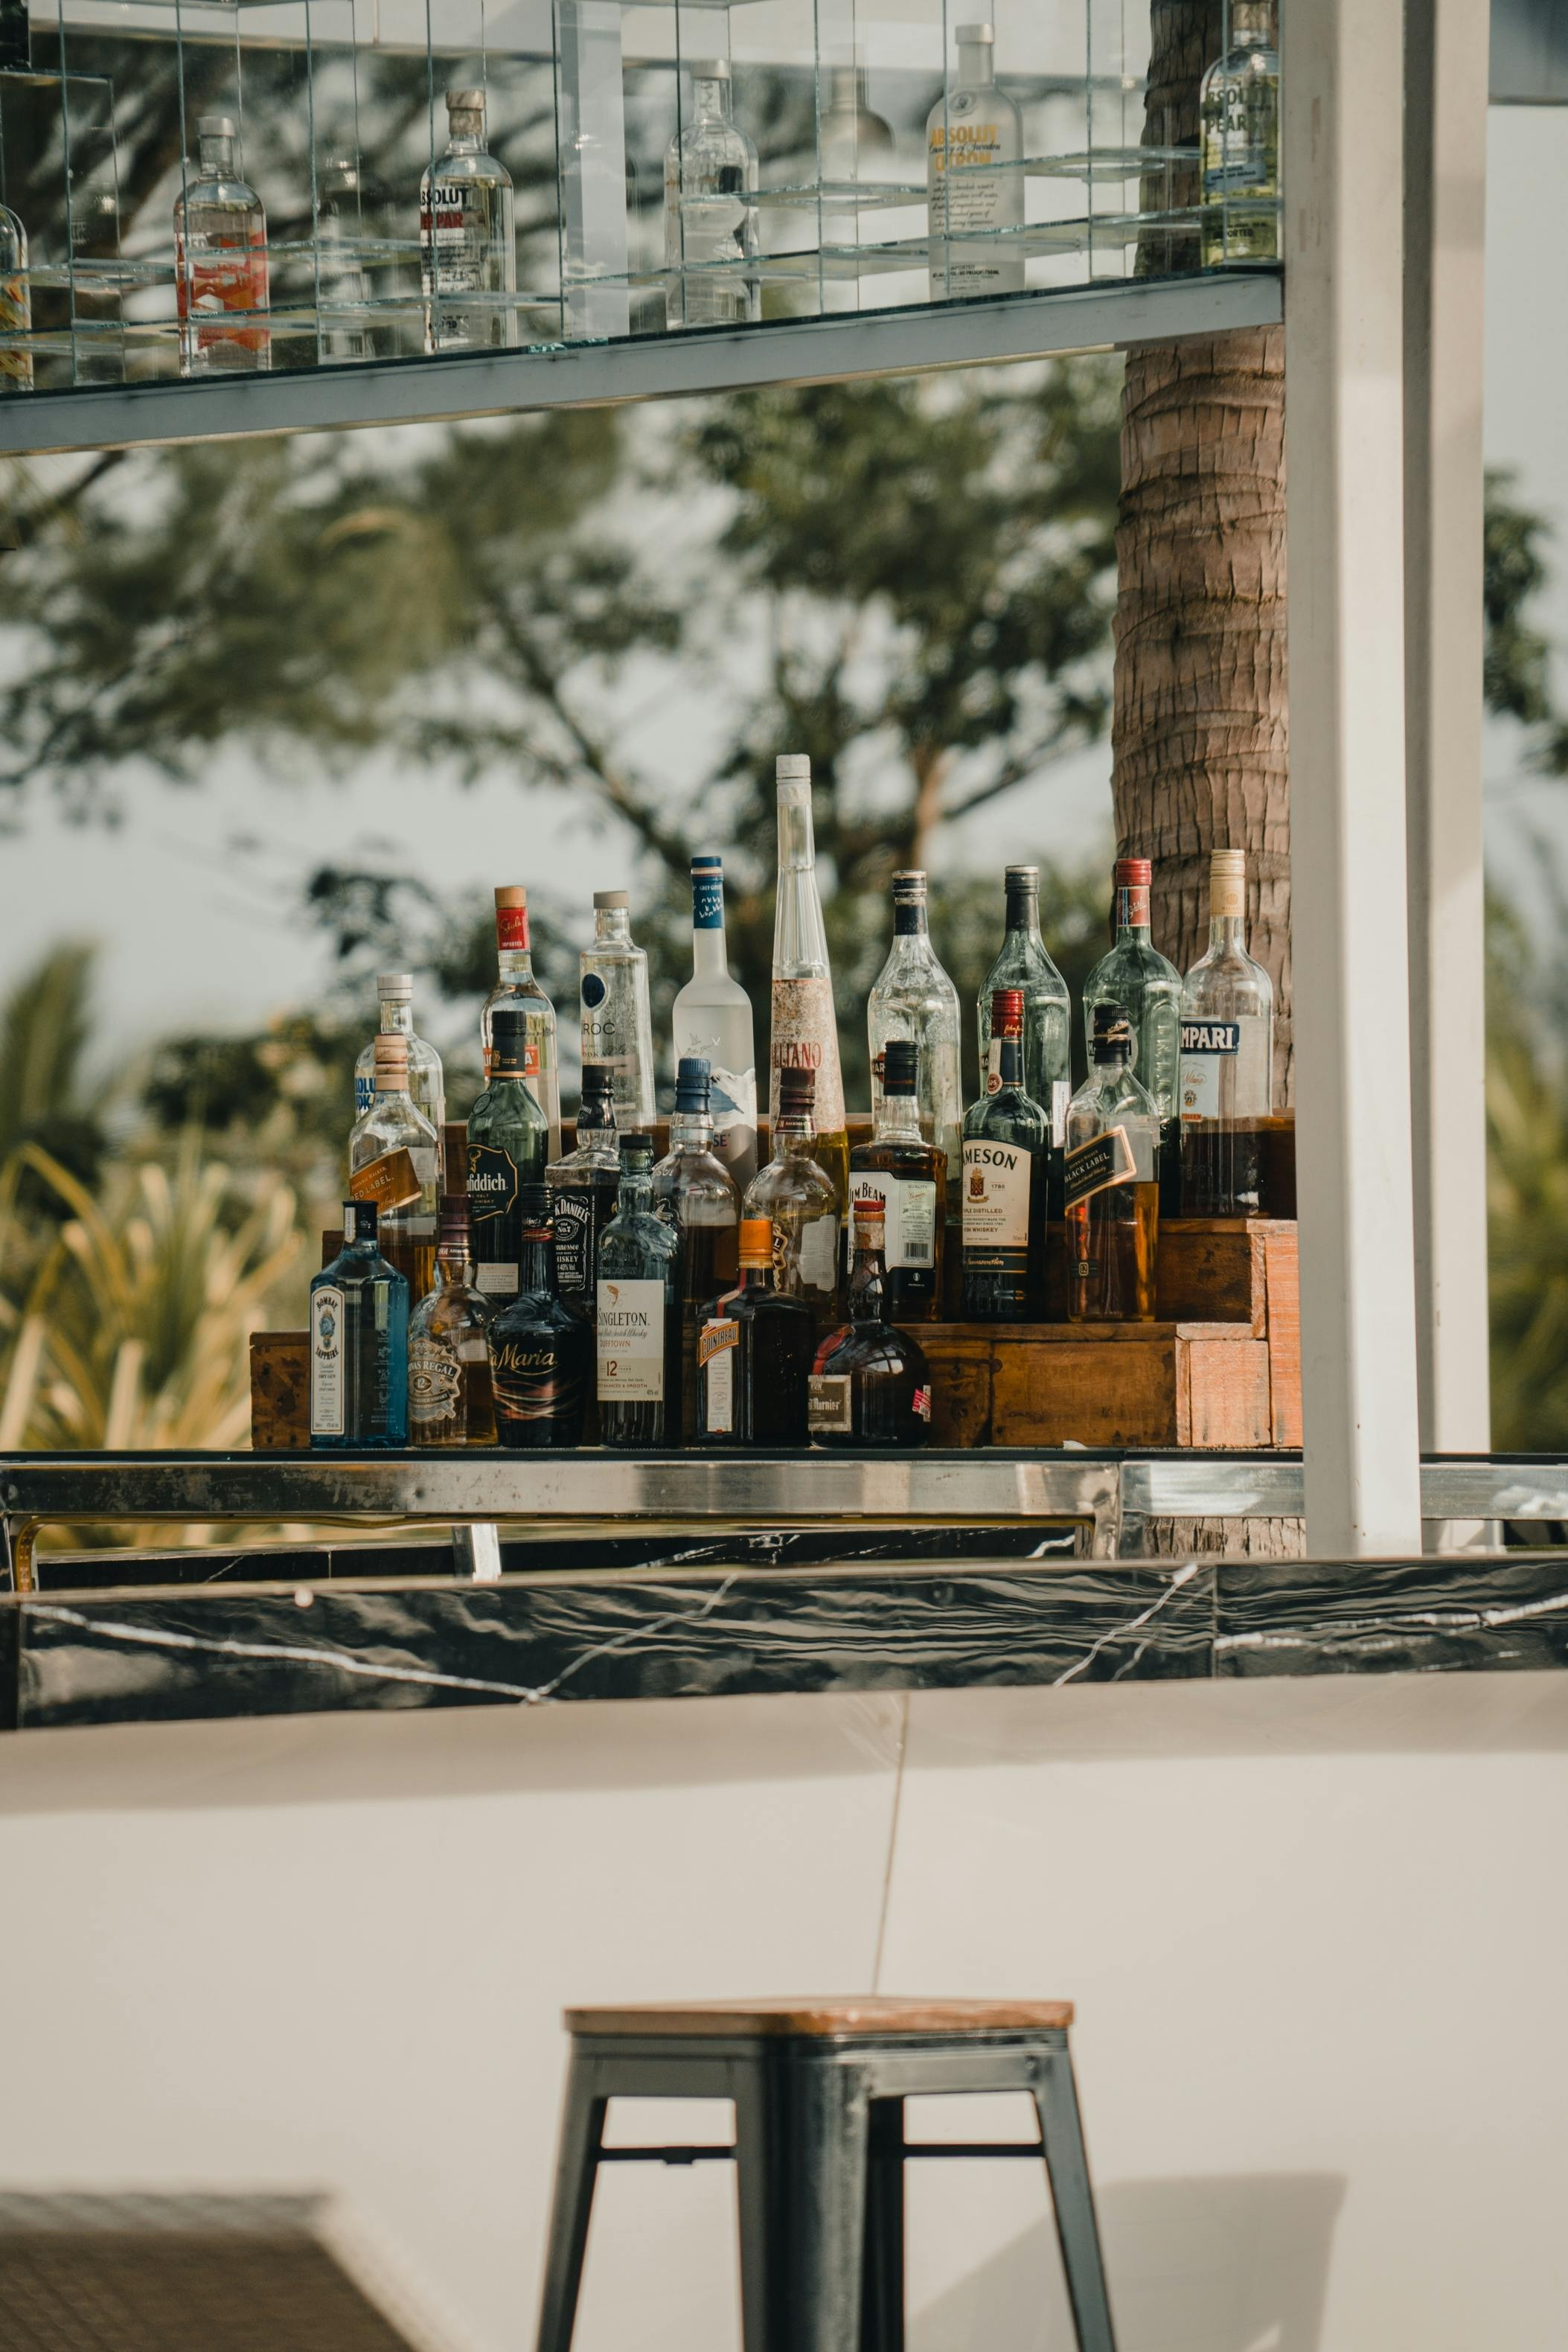


garrafa_037.jpg


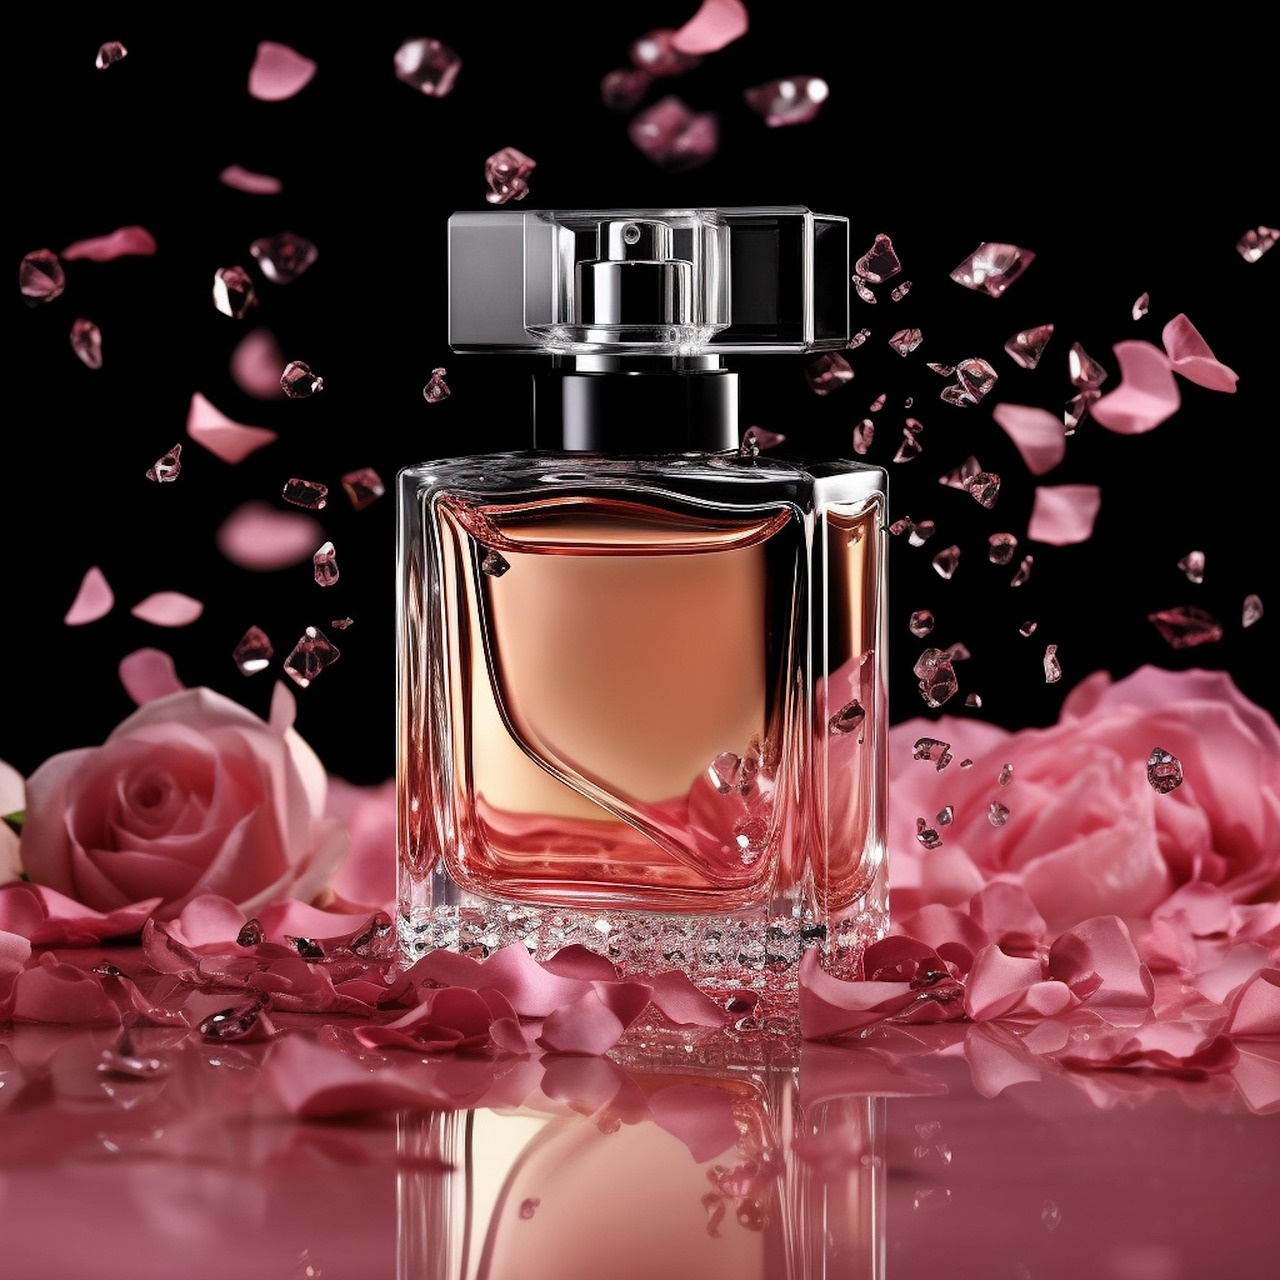


garrafa_038.jpg


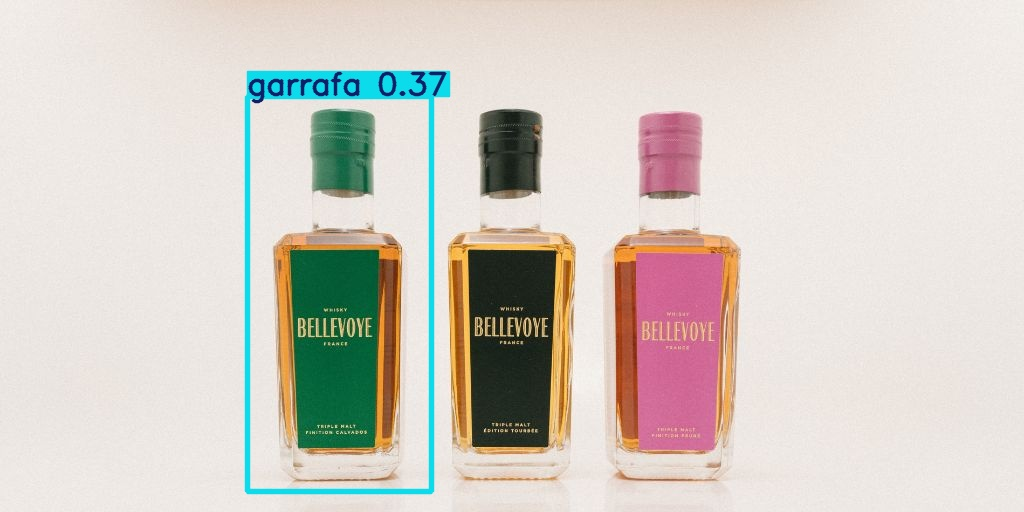


garrafa_039.jpg


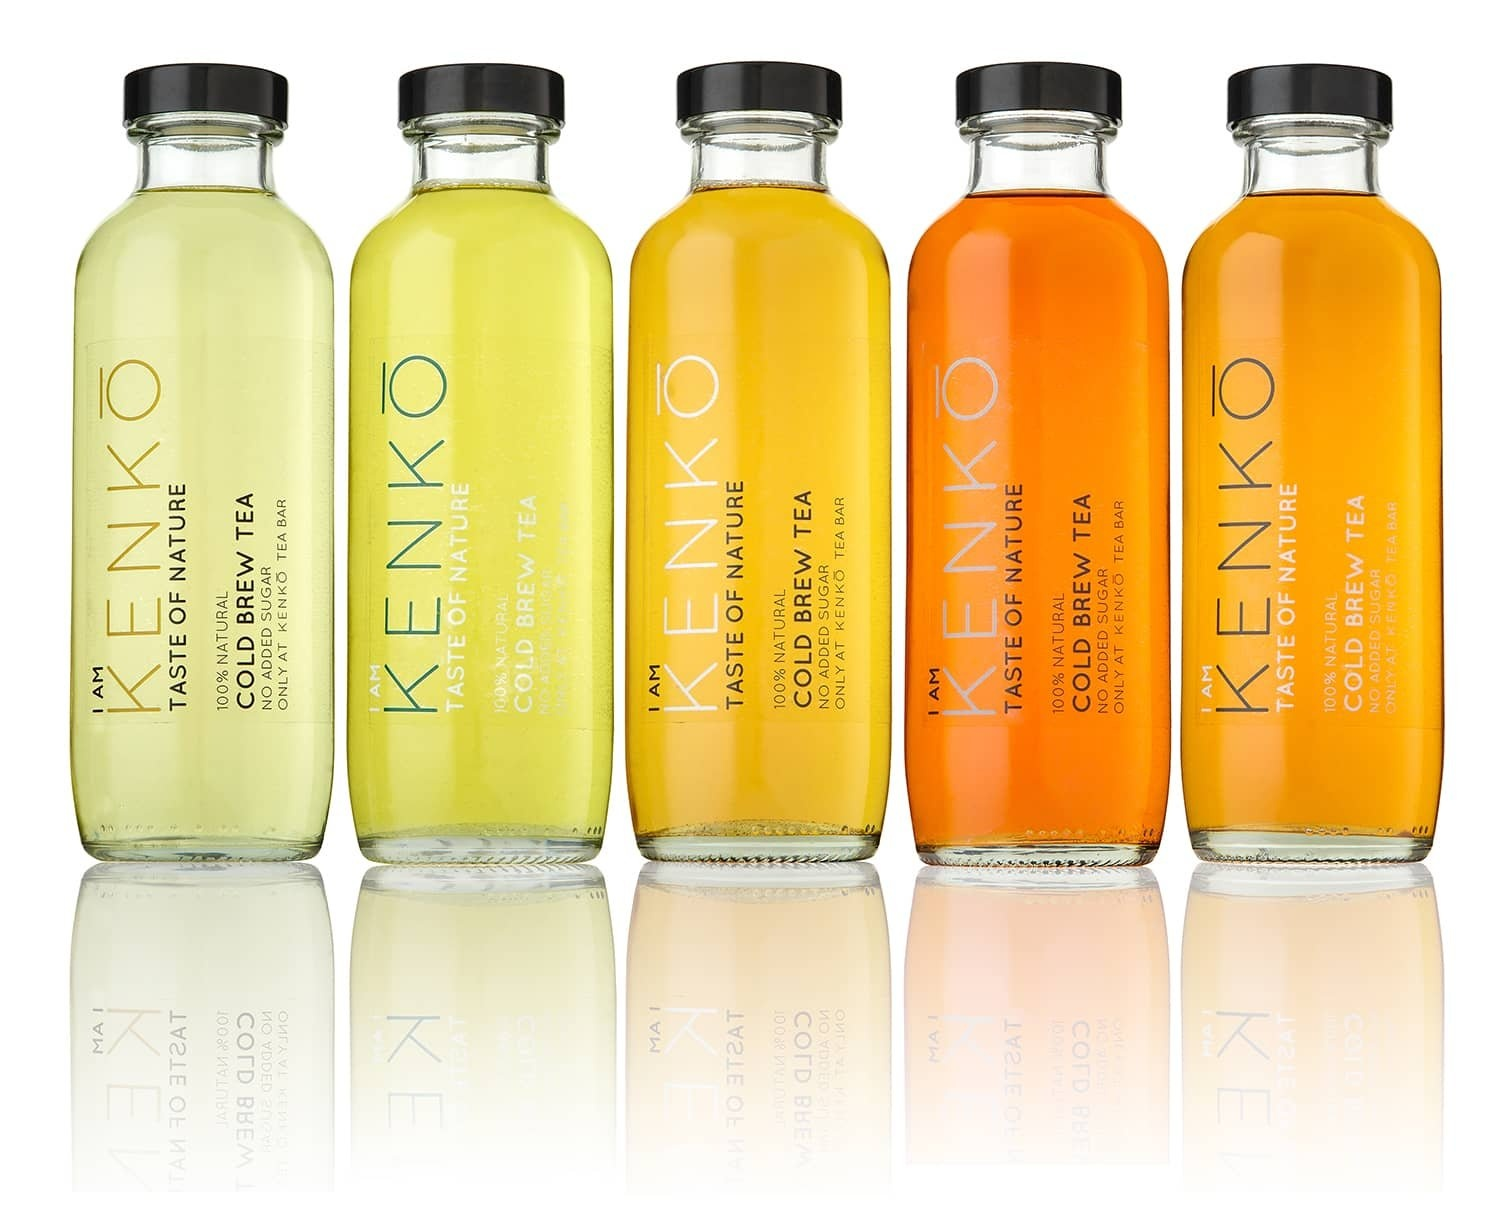


maca_036.jpg


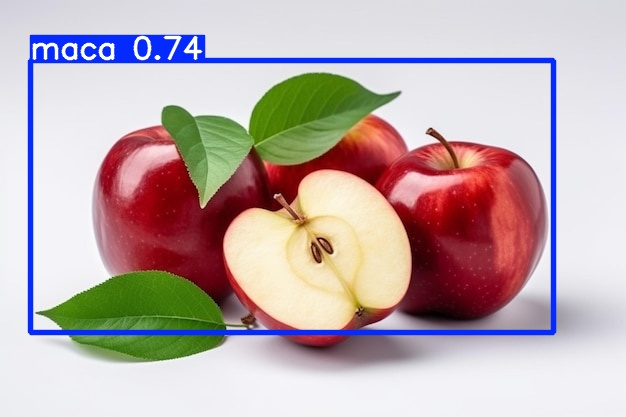


maca_037.jpg


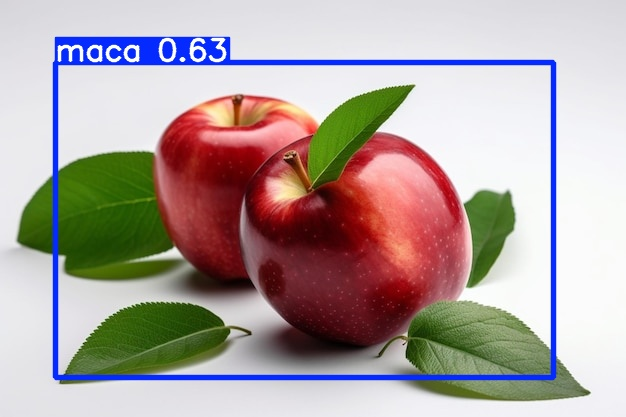


maca_038.jpg


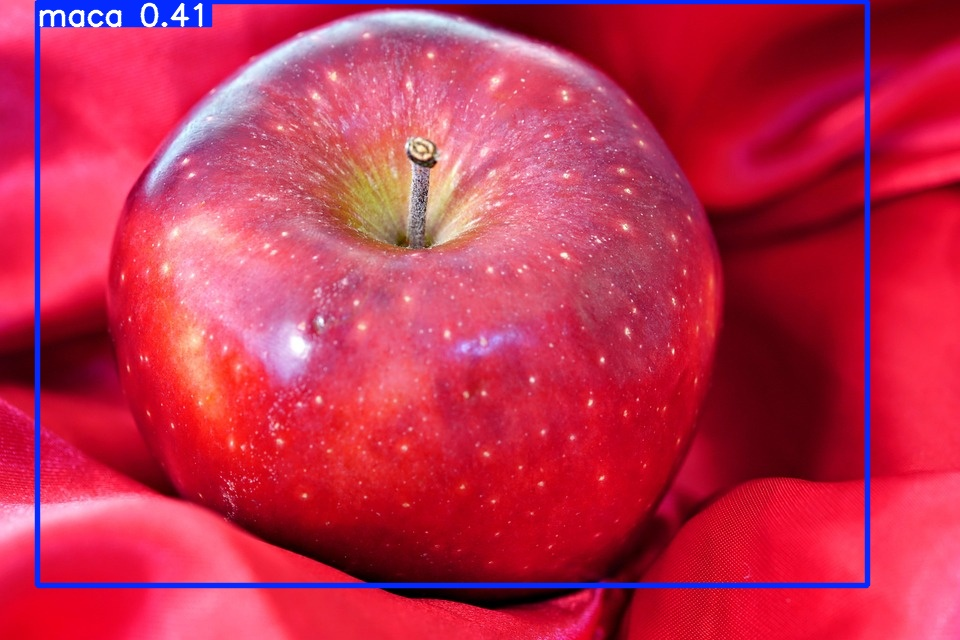


maca_039.jpg


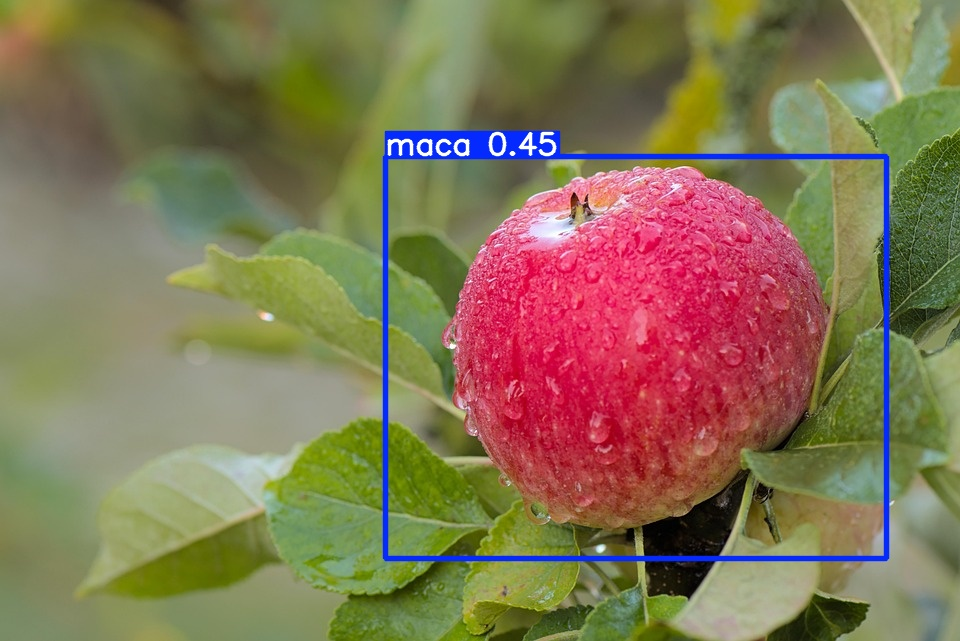

In [58]:
print('=========================================')
print('  RESULTADOS DO TESTE - 60 ÉPOCAS')
print('=========================================')
test_imgs_60 = sorted(glob.glob('runs/detect/teste_60ep/*.jpg') + glob.glob('runs/detect/teste_60ep/*.jpeg') + glob.glob('runs/detect/teste_60ep/*.png'))
for img_path in test_imgs_60:
    print(f'\n{os.path.basename(img_path)}')
    display(Image(filename=img_path, width=500))

## 9. Conclusões

### Comparação dos Resultados

| Métrica | 30 Épocas | 60 Épocas |
|---------|-----------|----------|
| mAP@0.5 | 0.5969 | 0.8076 |
| mAP@0.5:0.95 | 0.3402 | 0.5947 |
| Precision | 0.8875 | 1.0000 |
| Recall | 0.6250 | 0.7500 |
| Box Loss (Final) | 0.0480 | 0.0269 |

### Análise

**Impacto do número de épocas:**
- Com 30 épocas, o modelo já demonstra capacidade de distinguir maçãs de garrafas, uma vez que são objetos visualmente muito distintos em forma, cor e textura. No entanto, a precisão para garrafas foi baixa inicialmente.
- Com 60 épocas, houve uma melhora significativa em todas as métricas. O mAP@0.5 saltou de ~60% para ~81%, e a Precision atingiu o valor máximo, indicando que o modelo parou de gerar falsos positivos.
- O aumento de épocas permitiu que o modelo refinasse melhor os limites das bounding boxes (visto no aumento do mAP@0.5:0.95) e reduzisse a perda de localização (Box Loss).

**Pontos Fortes:**
- O YOLOv5 mostrou-se extremamente eficiente, processando as imagens de teste em milissegundos mesmo em CPU.
- O transfer learning permitiu resultados sólidos com apenas 64 imagens de treino.

**Limitações:**
- O dataset pequeno ainda é um risco para cenários com fundos complexos ou oclusões parciais.
- Observou-se que garrafas transparentes ou em ângulos específicos ainda podem ser desafiadoras comparadas às maçãs.

**Potencial para o cliente FarmTech Solutions:**
- A viabilidade técnica está comprovada. Para um ambiente de produção, recomenda-se expandir o dataset para ~500 imagens por classe para garantir robustez industrial.

In [63]:
# Configurações globais do Git
!git config --global user.email "diogo.zfo@gmail.com"
!git config --global user.name "diogoopereira"



In [64]:
!git init

Reinitialized existing Git repository in /content/yolov5/.git/
On branch main
Your branch and 'origin/master' have diverged,
and have 1 and 1 different commits each, respectively.
  (use "git pull" to merge the remote branch into yours)

nothing to commit, working tree clean
error: remote origin already exists.
fatal: could not read Username for 'https://github.com': No such device or address


In [65]:
!git add .

In [72]:
# Removendo workflows do GitHub que impedem o push com tokens simples
!rm -rf .github/
!git add .github/ --base || true
!git add .
!git commit -m "Removendo workflows para permitir push"

error: unknown option `base'
usage: git add [<options>] [--] <pathspec>...

    -n, --dry-run         dry run
    -v, --verbose         be verbose

    -i, --interactive     interactive picking
    -p, --patch           select hunks interactively
    -e, --edit            edit current diff and apply
    -f, --force           allow adding otherwise ignored files
    -u, --update          update tracked files
    --renormalize         renormalize EOL of tracked files (implies -u)
    -N, --intent-to-add   record only the fact that the path will be added later
    -A, --all             add changes from all tracked and untracked files
    --ignore-removal      ignore paths removed in the working tree (same as --no-all)
    --refresh             don't add, only refresh the index
    --ignore-errors       just skip files which cannot be added because of errors
    --ignore-missing      check if - even missing - files are ignored in dry run
    --sparse              allow updating entries out

In [73]:
!git commit -m "first commit"


On branch main
nothing to commit, working tree clean


In [74]:
!git branch -M main


In [75]:
# Removendo se já existir e adicionando com o Token de Acesso (PAT)
# Substitua SEU_TOKEN_AQUI pelo seu token do GitHub
TOKEN = ''SEU_TOKEN_AQUI'
REPO_URL = f'https://{TOKEN}@github.com/diogoopereira/Cap-1-OdespertarDaRede-Neural-.git'

!git remote remove origin
!git remote add origin {REPO_URL}
print('Remote origin configurado com sucesso.')

Remote origin configurado com sucesso.


In [76]:
# Agora o push deve funcionar sem pedir senha
!git push -u origin main

Enumerating objects: 14689, done.
Counting objects: 100% (14689/14689), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4958/4958), done.
Writing objects: 100% (14689/14689), 16.59 MiB | 15.25 MiB/s, done.
Total 14689 (delta 9728), reused 14679 (delta 9722), pack-reused 0
remote: Resolving deltas: 100% (9728/9728), done.
To https://github.com/diogoopereira/Cap-1-OdespertarDaRede-Neural-.git
 * [new branch]        main -> main
Branch 'main' set up to track remote branch 'main' from 'origin'.
